# Notebook 24 — Full Autonomous Pipeline: Perceive → Map → Plan → Act

This capstone notebook integrates **every component** from the preceding notebooks into a
single, closed-loop autonomous drone flight simulation.  The system executes the classic
autonomy loop that underpins real platforms such as **Skydio X10**, **DJI Avata 2**, and
the **PX4 autopilot**:

| Stage | Module | Reference NB |
|-------|--------|--------------|
| **1. Perceive** | Noisy IMU + GPS → EKF state estimation | NB 20 |
| **2. Map** | Depth rays → log-odds occupancy grid | NB 12 |
| **3. Plan** | A\*, RRT\*, APF on the live map | NB 21 |
| **4. Act** | SE(3) geometric controller → motor thrusts | NB 19 |

### Pipeline Architecture

The full autonomy loop contains four primary modules connected by feedback:

```
                        ┌─────────────────────────────────────────────┐
                        │              ENVIRONMENT                     │
                        │  (physics, obstacles, wind, other agents)    │
                        └──────┬────────────────────────────▲─────────┘
                               │ raw sensor data            │ motor commands
                               ▼                            │
  ┌──────────────────────────────────┐    ┌─────────────────┴──────────────┐
  │  1. PERCEIVE                      │    │  4. ACT                         │
  │  ─────────────────                │    │  ─────────────────              │
  │  IMU + GPS + Depth → EKF          │    │  SE(3) geometric controller    │
  │  Output: x̂_k (pose, vel, bias)   │    │  Input: trajectory + x̂_k      │
  │  Rate: 200–1000 Hz (predict)      │    │  Output: motor thrusts f_i     │
  │        10–30 Hz (update)          │    │  Rate: 100–500 Hz              │
  └──────────────┬───────────────────┘    └──────────────────▲─────────────┘
                 │ estimated state x̂_k                       │ reference trajectory τ*(t)
                 ▼                                           │
  ┌──────────────────────────────────┐    ┌─────────────────┴──────────────┐
  │  2. MAP                           │    │  3. PLAN                        │
  │  ─────────────────                │    │  ─────────────────              │
  │  Depth rays → log-odds update     │    │  A* / RRT* / APF on M_k        │
  │  Input: z_k, x̂_k, M_{k-1}       │    │  Input: M_k, x̂_k, x_goal      │
  │  Output: occupancy map M_k        │    │  Output: waypoint path → τ*(t) │
  │  Rate: 10–30 Hz                   │    │  Rate: 1–5 Hz (replan on event)│
  └──────────────┬───────────────────┘    └──────────────────▲─────────────┘
                 │ updated map M_k                           │
                 └───────────────────────────────────────────┘
                            FEEDBACK: new map triggers replanning
```

### Formal Module Input/Output Types

Each module is a well-defined function with explicit types:

| Module | Input | Output | State |
|--------|-------|--------|-------|
| **Perceive** | $z_k \in \mathbb{R}^m$ (raw sensor) | $\hat{x}_k \in \mathrm{SE}(3) \times \mathbb{R}^6$ (pose + vel) | $P_k \in \mathbb{R}^{15 \times 15}$ (EKF covariance) |
| **Map** | $(\hat{x}_k, z_k^{\text{depth}}, \mathcal{M}_{k-1})$ | $\mathcal{M}_k : \mathbb{Z}^3 \to \mathbb{R}$ (log-odds grid) | Per-voxel log-odds $l(c)$ |
| **Plan** | $(\mathcal{M}_k, \hat{x}_k, x_{\text{goal}})$ | $\tau^* : [0, T] \to \mathrm{SE}(3)$ (trajectory) | Search tree / wavefront |
| **Act** | $(\hat{x}_k, \tau^*(t))$ | $u_k = [f_1, f_2, f_3, f_4]^\top \in \mathbb{R}^4_{\geq 0}$ | PID integral terms |

### Timing Budget Breakdown

Real autonomous systems run each module at a different frequency dictated by
sensor rates, physical constraints, and available compute:

| Module | Frequency | Rationale |
|--------|----------:|-----------|
| **IMU read + EKF predict** | 200–1000 Hz | IMU delivers data at high rate; prediction is a single matrix multiply ($< 1\,\text{ms}$) |
| **GPS / VIO update** | 10–30 Hz | GPS runs at 10 Hz; visual–inertial at 15–30 Hz. Kalman update is $O(n^3)$ in state dim |
| **Depth → occupancy update** | 10–30 Hz | Matches depth camera frame rate. Ray-casting is parallelisable on GPU |
| **Path planning (A\*)** | 1–5 Hz | Only needed when map changes or goal moves. A\* on a 40³ grid takes 10–50 ms |
| **Trajectory generation** | 1–5 Hz | Triggered by replanning events. Polynomial or spline fitting in $< 5\,\text{ms}$ |
| **SE(3) controller** | 100–500 Hz | Must be faster than the rigid-body dynamics to ensure stability margins. Runs on MCU |
| **Motor mixing** | 500–1000 Hz | Simple linear algebra ($4 \times 4$ allocation matrix); negligible latency |

> **Rule of thumb**: inner loops (control) run $10\text{–}100\times$ faster than outer
> loops (planning).  This time-scale separation is what makes the modular design
> analytically tractable — each layer sees the layer below it as "instantaneous."

### Safety vs. Performance: Why Modular Beats End-to-End

End-to-end learned policies (e.g., a single neural network mapping sensor → motor
commands) can achieve impressive reactive performance but present serious challenges
for production deployment:

| Criterion | Modular pipeline | End-to-end learned |
|-----------|:----------------:|:------------------:|
| **Interpretability** | Each module's output is inspectable (pose, map, path) | Latent activations only |
| **Formal safety guarantees** | Lyapunov stability for controller; completeness for A\* | No provable guarantees |
| **Failure isolation** | A mapping fault does not corrupt the controller | Any neuron can affect any output |
| **Certification** | Module-level V\&V possible (DO-178C, JARUS SORA) | No accepted certification path yet |
| **Sim-to-real transfer** | Physics-based modules transfer directly | Domain gap requires fine-tuning |
| **Upgrade path** | Swap one module (e.g., better planner) without retraining | Must retrain the entire network |

Production systems (PX4, Skydio, DJI) therefore use a **modular architecture with
explicit safety contracts at each interface**, while keeping the door open for learned
components inside individual modules (e.g., learned depth estimation inside Perceive,
learned local planner inside Plan).

---

We will run through:

1. Building a rich 3-D test environment with buildings, trees, and dynamic obstacles.
2. A simulated depth sensor with ray-casting into the occupancy grid.
3. Incremental mapping as the drone explores.
4. Autonomous frontier-based exploration.
5. Goal-directed navigation with replanning.
6. Noisy state estimation via EKF in the control loop.
7. Multiple mission types (survey, inspection, search, delivery).
8. Comprehensive performance metrics.
9. Classical vs. learned (RL) navigation comparison.
10. Failure mode analysis.
11. Full system architecture summary.

### Mathematical foundation

The autonomy loop at each time-step $k$:

$$
\underbrace{z_k}_{\text{sensor}} \;\xrightarrow{\text{EKF}}\;
\hat{x}_k \;\xrightarrow{\text{Map}}\;
\mathcal{M}_k \;\xrightarrow{\text{Plan}}\;
\tau_k^* \;\xrightarrow{\text{Control}}\;
u_k \;\xrightarrow{\text{Dynamics}}\;
x_{k+1}
$$

In [1]:
import sys, os, time, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches

from src.drone import (
    QuadrotorParams, QuadrotorState, simulate_step,
    PIDController, SE3Controller,
    generate_waypoint_trajectory, simulate_trajectory,
    hat, vee, GRAVITY,
)
from src.path_planning import (
    OccupancyGrid3D, astar_3d, rrt_star,
    artificial_potential_field, create_random_obstacles,
    smooth_path, resample_path, path_length,
)
from src.rl_agents import PPO, SAC, DroneHoverEnv, DroneNavigationEnv, MLPPolicy, MLPValueFunction
from src.ekf import VIO_EKF
from src.occupancy import OccupancyGrid
from src.eval import compute_ate, compute_rpe

np.random.seed(42)
plt.rcParams.update({'figure.max_open_warning': 0})

## Mathematical Formalization: The Perceive-Map-Plan-Act Loop

The autonomous navigation pipeline repeats a four-stage loop at each discrete
time step $t$. Below we formalize each stage as a mathematical operator.

### Stage 1 — Perception (Observation Model)

The drone obtains a noisy measurement $z_t$ of the true state $x_t$:

$$
z_t = h(x_t) + v_t, \qquad v_t \sim \mathcal{N}(0, R_t)
$$

where $h : \mathbb{R}^n \to \mathbb{R}^m$ is the (possibly nonlinear) sensor model
and $v_t$ is zero-mean Gaussian measurement noise with covariance $R_t$.

For the EKF, the linearized observation Jacobian is:

$$
H_t = \left.\frac{\partial h}{\partial x}\right|_{\hat{x}_t}
$$

### Stage 2 — Mapping (Recursive Map Update)

The map $M_t$ is updated given the new observation $z_t$ and the current
pose estimate $\hat{x}_t$:

$$
M_t = f\!\left(M_{t-1},\, z_t,\, \hat{x}_t\right)
$$

For log-odds occupancy grids, each cell $c$ is updated independently:

$$
l_t(c) = l_{t-1}(c) + l_{\mathrm{sensor}}(c \mid z_t, \hat{x}_t) - l_0
$$

where $l_0 = \log\!\frac{p_0}{1 - p_0}$ is the prior and
$l_{\mathrm{sensor}}$ is the inverse-sensor model.

The occupancy probability is recovered via the logistic function:

$$
P(\text{occupied} \mid z_{1:t}) = 1 - \frac{1}{1 + \exp(l_t(c))}
$$

### Stage 3 — Planning (Cost Minimization)

Given the current map $M_t$, state estimate $\hat{x}_t$, and goal $x_{\mathrm{goal}}$,
the planner finds the optimal policy (or path):

$$
\pi^* = \arg\min_{\pi} \; J(\pi,\, M_t,\, \hat{x}_t,\, x_{\mathrm{goal}})
$$

where the cost functional $J$ typically combines path length and safety:

$$
J(\pi) = \int_0^{T} \left[ \|\dot{q}(t)\| + \lambda \cdot c_{\text{collision}}(q(t), M_t) \right] dt
$$

For A*, this reduces to finding the minimum-cost graph path
$f(n) = g(n) + h(n)$ on the discretized occupancy grid.

### Stage 4 — Control (Feedback Law)

The controller generates motor commands $u_t$ to track the planned reference
trajectory $x_{\mathrm{ref},t}$:

$$
u_t = K\!\left(\hat{x}_t,\, x_{\mathrm{ref},t}\right)
$$

For the SE(3) geometric controller (Lee *et al.*, 2010), the control law
computes the desired wrench from the rotation and position errors:

$$
f = -k_x e_x - k_v e_v + mg\,\hat{e}_3 + m\ddot{x}_d
$$

$$
\tau = -k_R e_R - k_\omega e_\omega + \omega \times J\omega
$$

where $e_x = x - x_d$, $e_v = v - v_d$, and $e_R = \frac{1}{2}(R_d^\top R - R^\top R_d)^\vee$.

### Closed-Loop Stability

Under the SE(3) controller, if the initial tracking errors are sufficiently small,
the system is **almost-globally asymptotically stable** on $\mathrm{SO}(3) \times \mathbb{R}^3$
(Lee *et al.*, 2010, Theorem 2). The composite Lyapunov function is:

$$
\mathcal{V} = \frac{1}{2} k_x \|e_x\|^2 + \frac{1}{2} m \|e_v\|^2
+ \frac{1}{2} k_R \operatorname{tr}(I - R_d^\top R) + \frac{1}{2} e_\omega^\top J e_\omega
$$

## 1. Environment Setup

We create a structured 3-D urban environment for autonomous navigation, populated with:

- A **ground plane** at $z = 0$
- **Buildings** — tall rectangular prisms (axis-aligned boxes)
- **Trees** — cylinders with varying radii and heights
- **Dynamic obstacles** — spheres that move along predefined trajectories

The environment is represented as a binary `OccupancyGrid3D` for path planning and a
probabilistic `OccupancyGrid` (log-odds) for incremental mapping.

### Occupancy Grid Representation: Log-Odds for Numerical Stability

A naïve occupancy grid stores $P(\text{occ} \mid z_{1:t}) \in [0, 1]$ per voxel, but
repeated Bayesian updates quickly push probabilities toward 0 or 1, causing floating-point
underflow.  The standard solution is to work in **log-odds** space:

$$
l(c) \;=\; \log \frac{P(\text{occ}(c))}{1 - P(\text{occ}(c))}
\;\in\; (-\infty, +\infty)
$$

The Bayesian update then reduces to simple **addition**:

$$
l_t(c) \;=\; \underbrace{l_{t-1}(c)}_{\text{prior from previous step}}
\;+\; \underbrace{l_{\text{sensor}}(c \mid z_t, \hat{x}_t)}_{\text{inverse sensor model}}
\;-\; \underbrace{l_0}_{\text{prior offset}}
$$

where $l_0 = \log\frac{p_0}{1 - p_0}$ (zero when $p_0 = 0.5$).  To recover probability:

$$
P(\text{occ}(c) \mid z_{1:t}) = 1 - \frac{1}{1 + \exp(l_t(c))}
$$

**Why log-odds?** (1) Addition is cheaper than the full Bayes formula. (2) Values never
saturate to exactly 0 or 1 — the map remains correctable.  (3) Clamping
$l \in [l_{\min}, l_{\max}]$ bounds confidence, preventing a single spurious reading from
permanently corrupting a cell.

### TSDF vs. Binary Occupancy

Our grid stores binary (occupied / free) or probabilistic occupancy.  An alternative used
by dense reconstruction systems (e.g., KinectFusion, Voxblox) is the **Truncated Signed
Distance Function (TSDF)**:

| Property | Binary / log-odds occupancy | TSDF |
|----------|:---------------------------:|:----:|
| **Cell value** | $l(c) \in \mathbb{R}$ (log-odds of occupancy) | $d(c) \in [-\delta, +\delta]$ (signed distance to nearest surface) |
| **Surface extraction** | Threshold at $l = 0$ | Zero-crossing of $d(c) = 0$ (marching cubes) |
| **Gradient information** | No — binary boundary only | Yes — $\nabla d$ points toward the surface |
| **Use in planning** | A\*, RRT\* on binary grid | Optimization-based planners can use $\nabla d$ for smooth cost |
| **Fusion rule** | Log-odds addition | Weighted running average: $d_t = \frac{W_{t-1} d_{t-1} + w_t d_{\text{new}}}{W_{t-1} + w_t}$ |
| **Compute cost** | Low (per-voxel scalar add) | Moderate (distance projection per voxel) |

The key advantage of TSDF is that the signed distance field provides a **smooth gradient**
$\nabla d(c)$ everywhere.  Optimization-based planners (CHOMP, TrajOpt) can directly
minimize a cost like $\int \|\dot{q}\|^2 + \lambda \max(0, \epsilon - d(q))^2 \, dt$,
following the distance gradient to push the trajectory away from obstacles.  Our pipeline
uses log-odds occupancy because A\* and RRT\* need only free/occupied queries, not
gradients.

### Map Update: The Inverse Sensor Model

The term $l_{\text{sensor}}(c \mid z_t, \hat{x}_t)$ is the **inverse sensor model** — it
answers: "given that we observed depth $z_t$ from pose $\hat{x}_t$, what evidence does
this provide about cell $c$?"

For a depth-camera ray passing through voxel $c$ at range $r_c$ with measured depth $z$:

$$
l_{\text{sensor}}(c) =
\begin{cases}
l_{\text{occ}}  & \text{if } |r_c - z| < \tfrac{\Delta}{2} \quad \text{(hit: near the surface)} \\
l_{\text{free}} & \text{if } r_c < z - \tfrac{\Delta}{2} \quad \text{(traversed: ray passed through)} \\
0               & \text{otherwise} \quad \text{(no information)}
\end{cases}
$$

where $\Delta$ is the surface thickness (≈ 1–2 voxel widths), $l_{\text{occ}} > 0$
(typically +0.85), and $l_{\text{free}} < 0$ (typically −0.4).  Because log-odds are
additive, **multiple observations fuse automatically**: $N$ rays passing through a cell
contribute $N \cdot l_{\text{free}}$, driving it toward "definitely free," while a single
hit contributes $l_{\text{occ}}$.  The asymmetry $|l_{\text{free}}| < l_{\text{occ}}$
reflects the prior that one positive detection is stronger evidence than one negative
(a miss may be due to the ray missing a thin obstacle).

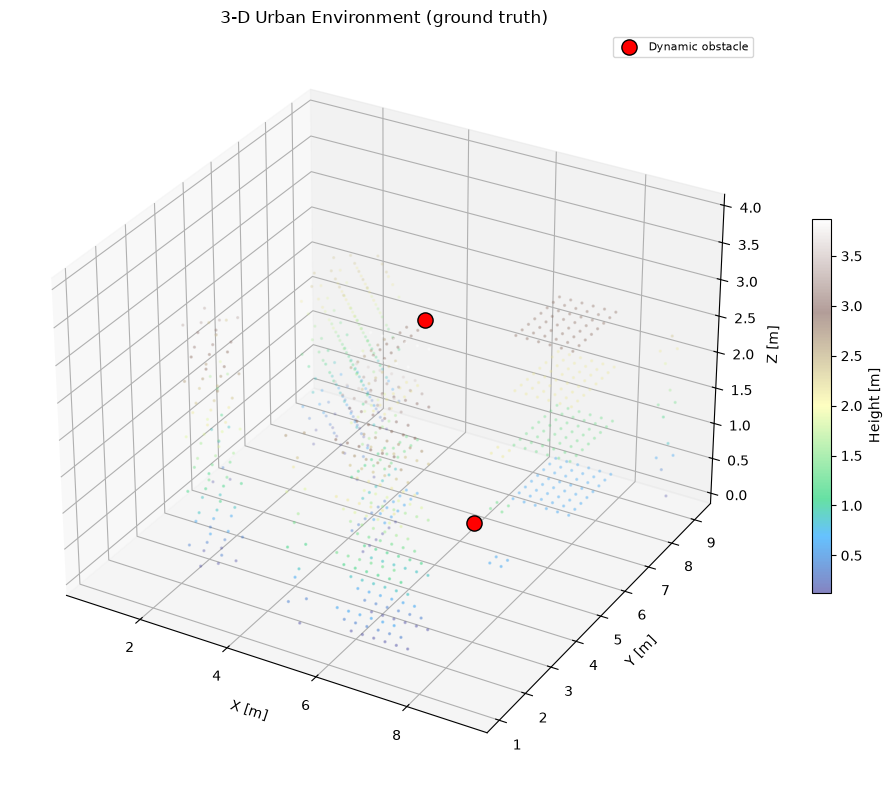

Grid shape: (np.int64(40), np.int64(40), np.int64(20))  (32,000 voxels)
Occupied:   2,336 voxels  (7.3%)
Resolution: 0.25 m


In [2]:
# ---------------------------------------------------------------------------
#  Environment configuration
# ---------------------------------------------------------------------------
ENV_SIZE = np.array([10.0, 10.0, 5.0])   # metres
RESOLUTION = 0.25                          # voxel size
GRID_SHAPE = tuple((ENV_SIZE / RESOLUTION).astype(int))  # (40, 40, 20)
ORIGIN = np.zeros(3)

gt_grid = np.zeros(GRID_SHAPE, dtype=bool)

def fill_box(grid, lo, hi, res=RESOLUTION, origin=ORIGIN):
    """Mark voxels inside an axis-aligned box as occupied."""
    idx_lo = np.floor((lo - origin) / res).astype(int)
    idx_hi = np.ceil((hi - origin) / res).astype(int)
    idx_lo = np.clip(idx_lo, 0, np.array(grid.shape) - 1)
    idx_hi = np.clip(idx_hi, 0, np.array(grid.shape))
    grid[idx_lo[0]:idx_hi[0], idx_lo[1]:idx_hi[1], idx_lo[2]:idx_hi[2]] = True

def fill_cylinder(grid, centre_xy, radius, z_lo, z_hi, res=RESOLUTION, origin=ORIGIN):
    """Mark voxels inside a vertical cylinder as occupied."""
    ix = np.arange(grid.shape[0])
    iy = np.arange(grid.shape[1])
    iz = np.arange(grid.shape[2])
    wx = origin[0] + (ix + 0.5) * res
    wy = origin[1] + (iy + 0.5) * res
    wz = origin[2] + (iz + 0.5) * res
    WX, WY, WZ = np.meshgrid(wx, wy, wz, indexing='ij')
    dist_sq = (WX - centre_xy[0])**2 + (WY - centre_xy[1])**2
    mask = (dist_sq <= radius**2) & (WZ >= z_lo) & (WZ <= z_hi)
    grid[mask] = True

# --- Ground plane (z = 0 slab) ---
fill_box(gt_grid, [0, 0, -0.1], [10, 10, 0.0])

# --- Buildings ---
buildings = [
    ([2.0, 2.0, 0.0], [3.0, 3.0, 3.5]),
    ([6.0, 1.0, 0.0], [7.5, 2.5, 4.0]),
    ([7.0, 6.0, 0.0], [8.5, 8.0, 3.0]),
    ([1.5, 7.0, 0.0], [3.0, 9.0, 2.5]),
    ([4.5, 4.0, 0.0], [5.5, 5.5, 3.0]),
]
for lo, hi in buildings:
    fill_box(gt_grid, lo, hi)

# --- Trees (cylinders) ---
trees = [
    ([1.0, 5.0], 0.3, 0.0, 2.5),
    ([5.0, 1.5], 0.35, 0.0, 2.8),
    ([8.0, 4.0], 0.3, 0.0, 2.2),
    ([3.5, 6.5], 0.25, 0.0, 2.0),
    ([9.0, 9.0], 0.3, 0.0, 2.4),
]
for cxy, r, zlo, zhi in trees:
    fill_cylinder(gt_grid, cxy, r, zlo, zhi)

gt_occ_grid = OccupancyGrid3D(gt_grid.copy(), RESOLUTION, ORIGIN.copy())

# ---------------------------------------------------------------------------
#  Dynamic obstacles (computed at query time, not baked into grid)
# ---------------------------------------------------------------------------
dynamic_obstacles = [
    {"centre0": np.array([4.0, 8.0, 2.0]), "velocity": np.array([0.3, -0.2, 0.0]), "radius": 0.4},
    {"centre0": np.array([8.0, 3.0, 1.5]), "velocity": np.array([-0.2, 0.3, 0.0]), "radius": 0.35},
]

def dynamic_obs_position(obs, t):
    pos = obs["centre0"] + obs["velocity"] * t
    pos = np.clip(pos, [0.5, 0.5, 0.5], ENV_SIZE - 0.5)
    return pos

# ---------------------------------------------------------------------------
#  Visualisation
# ---------------------------------------------------------------------------
occ_idx = np.argwhere(gt_grid)
occ_world = ORIGIN + (occ_idx + 0.5) * RESOLUTION
z_vals = occ_world[:, 2]

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(occ_world[::3, 0], occ_world[::3, 1], occ_world[::3, 2],
                c=z_vals[::3], cmap='terrain', s=2, alpha=0.6)
for obs in dynamic_obstacles:
    p = obs["centre0"]
    ax.scatter(*p, s=120, c='red', marker='o', edgecolors='k', zorder=5, label='Dynamic obstacle')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
ax.set_title('3-D Urban Environment (ground truth)')
handles, lbls = ax.get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8)
fig.colorbar(sc, ax=ax, shrink=0.5, label='Height [m]')
plt.tight_layout(); plt.show()

n_occ = int(gt_grid.sum())
n_total = int(np.prod(GRID_SHAPE))
print(f"Grid shape: {GRID_SHAPE}  ({n_total:,} voxels)")
print(f"Occupied:   {n_occ:,} voxels  ({100*n_occ/n_total:.1f}%)")
print(f"Resolution: {RESOLUTION} m")

## 2. The Perception Module

A simulated depth sensor suite.  For the drone's current pose $(\mathbf{p}, R)$, we:

1. **Cast rays** into the occupancy grid to obtain depth readings.
2. **Convert** depth to a 3-D point cloud in the world frame.
3. Feed the point cloud into the incremental mapping pipeline.

The sensor model produces a fan of $N_\theta \times N_\phi$ rays spanning a configurable
field of view (FoV).  Each ray marches through voxels using half-resolution steps until it
hits an occupied cell or exceeds `max_range`.

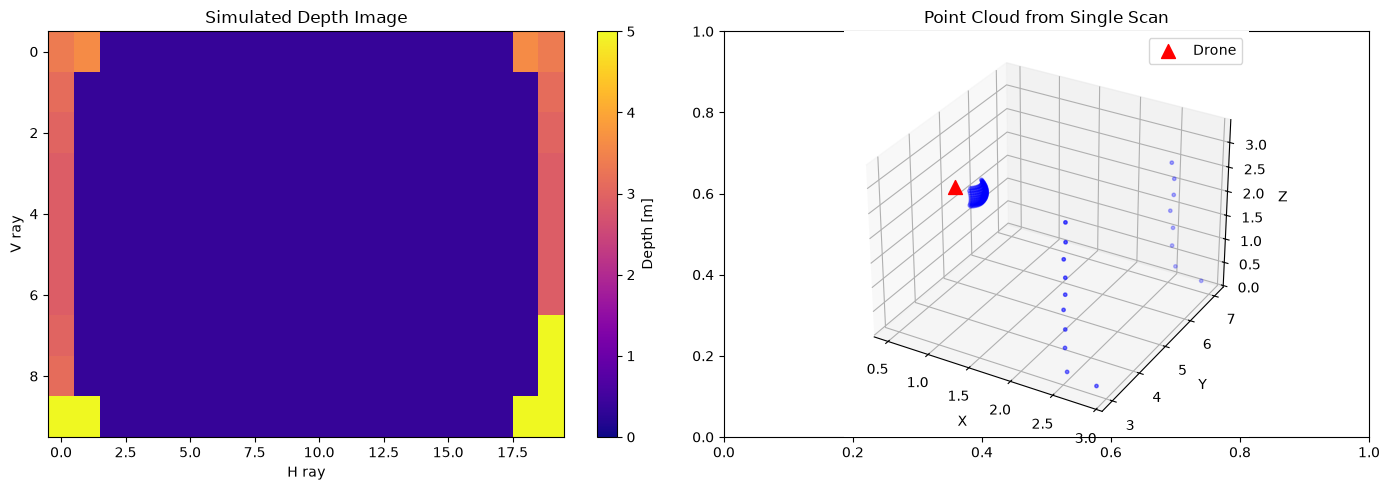

Rays cast: 200
Hits:      194
Min depth: 0.38 m
Max depth: 3.62 m


In [3]:
class SimulatedDepthSensor:
    """Simulated depth sensor via ray-casting into an OccupancyGrid3D."""

    def __init__(self, h_fov=np.pi/2, v_fov=np.pi/3, h_rays=24, v_rays=12, max_range=5.0):
        self.h_fov = h_fov
        self.v_fov = v_fov
        self.h_rays = h_rays
        self.v_rays = v_rays
        self.max_range = max_range
        h_angles = np.linspace(-h_fov/2, h_fov/2, h_rays)
        v_angles = np.linspace(-v_fov/2, v_fov/2, v_rays)
        self.H, self.V = np.meshgrid(h_angles, v_angles)
        self.ray_dirs_body = np.stack([
            np.cos(self.V) * np.cos(self.H),
            np.cos(self.V) * np.sin(self.H),
            np.sin(self.V),
        ], axis=-1)  # (v_rays, h_rays, 3)

    def cast(self, position, rotation, grid):
        """Return (depths, points_world). depths shape (v_rays, h_rays)."""
        depths = np.full((self.v_rays, self.h_rays), self.max_range)
        points = []
        step = grid.resolution * 0.5
        for vi in range(self.v_rays):
            for hi in range(self.h_rays):
                d_body = self.ray_dirs_body[vi, hi]
                d_world = rotation @ d_body
                for t in np.arange(step, self.max_range, step):
                    pt = position + t * d_world
                    if np.any(pt < grid.origin) or np.any(pt >= grid.origin + np.array(grid.shape) * grid.resolution):
                        break
                    idx = grid.world_to_grid(pt)
                    if grid.is_valid(idx) and grid.grid[idx]:
                        depths[vi, hi] = t
                        points.append(pt.copy())
                        break
        points = np.array(points) if points else np.empty((0, 3))
        return depths, points

sensor = SimulatedDepthSensor(h_rays=20, v_rays=10, max_range=5.0)

# Demo: cast from a hover position
demo_pos = np.array([0.5, 5.0, 2.0])
demo_R = np.eye(3)  # facing +X
depths, pts_world = sensor.cast(demo_pos, demo_R, gt_occ_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(depths, cmap='plasma', vmin=0, vmax=sensor.max_range, aspect='auto')
axes[0].set_title('Simulated Depth Image'); axes[0].set_xlabel('H ray'); axes[0].set_ylabel('V ray')
fig.colorbar(im, ax=axes[0], label='Depth [m]')

ax3 = fig.add_subplot(122, projection='3d')
if len(pts_world) > 0:
    ax3.scatter(pts_world[:, 0], pts_world[:, 1], pts_world[:, 2], c='blue', s=6, alpha=0.8)
ax3.scatter(*demo_pos, s=100, c='red', marker='^', label='Drone')
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.set_title('Point Cloud from Single Scan'); ax3.legend()
plt.tight_layout(); plt.show()

print(f"Rays cast: {sensor.h_rays * sensor.v_rays}")
print(f"Hits:      {len(pts_world)}")
print(f"Min depth: {depths[depths < sensor.max_range].min():.2f} m" if np.any(depths < sensor.max_range) else "No hits")
print(f"Max depth: {depths[depths < sensor.max_range].max():.2f} m" if np.any(depths < sensor.max_range) else "")

## 3. Incremental Mapping

We start with an **empty map** and build it incrementally as the drone moves along a
pre-planned path.  At each waypoint the depth sensor fires, and we update the occupancy
grid using the standard log-odds update rule:

$$
l(m \mid z_{1:t}) = l(m \mid z_{1:t-1}) + l(m \mid z_t) - l_0
$$

where $l_0 = \log\frac{p_0}{1 - p_0}$ is the prior (zero for uniform prior $p_0 = 0.5$).

The Bresenham-based ray-casting inside `OccupancyGrid.update()` marks traversed voxels as
free ($l_{\text{free}} = -0.4$) and the end-point voxel as occupied
($l_{\text{occ}} = +0.85$).

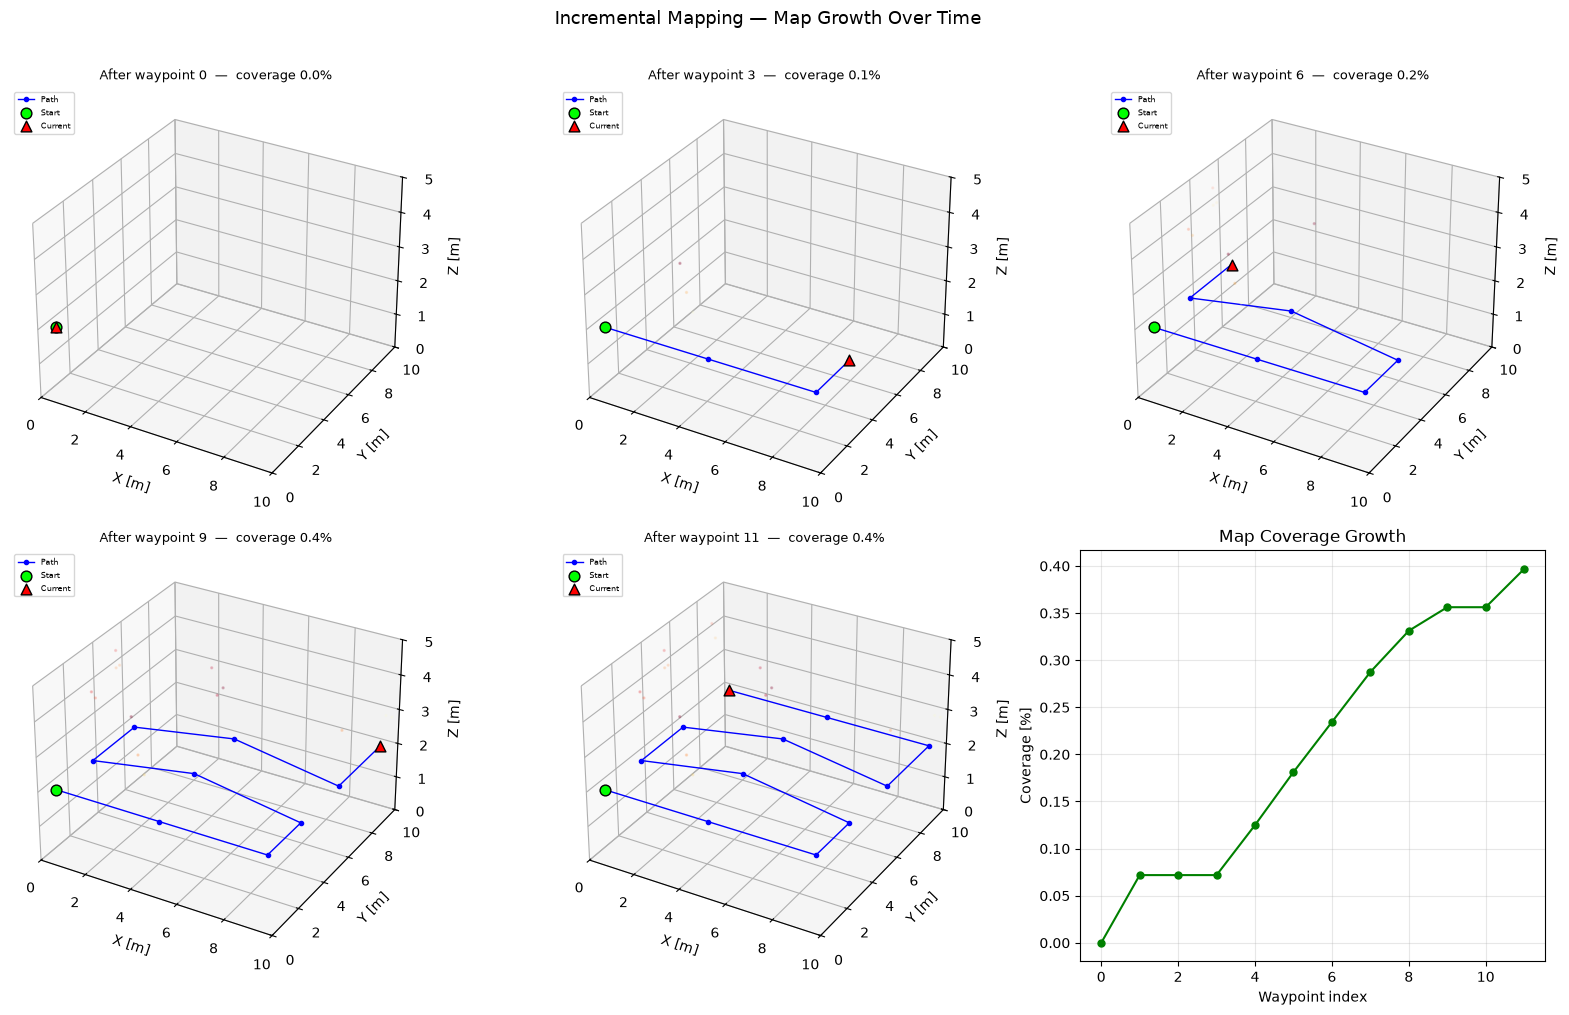

Final map coverage: 0.4%


In [4]:
# Incremental mapping along a pre-planned exploration path
bounds = np.array([[0, ENV_SIZE[0]], [0, ENV_SIZE[1]], [0, ENV_SIZE[2]]])
inc_map = OccupancyGrid(bounds, resolution=RESOLUTION)

exploration_waypoints = np.array([
    [0.5, 0.5, 2.0], [5.0, 0.5, 2.0], [9.5, 0.5, 2.0],
    [9.5, 3.0, 2.0], [5.0, 3.0, 2.5], [0.5, 3.0, 2.0],
    [0.5, 6.0, 2.0], [5.0, 6.0, 2.5], [9.5, 6.0, 2.0],
    [9.5, 9.5, 2.0], [5.0, 9.5, 2.0], [0.5, 9.5, 2.0],
])

K_cam = np.array([[200, 0, 80], [0, 200, 60], [0, 0, 1]], dtype=np.float64)

snapshot_indices = [0, 3, 6, 9, 11]
snapshots = []
coverage_hist = []

for wi, wp in enumerate(exploration_waypoints):
    yaw = np.arctan2(0.5, 1.0) if wi == 0 else np.arctan2(
        exploration_waypoints[min(wi+1, len(exploration_waypoints)-1)][1] - wp[1],
        exploration_waypoints[min(wi+1, len(exploration_waypoints)-1)][0] - wp[0]
    )
    cy, sy = np.cos(yaw), np.sin(yaw)
    R_cam = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]], dtype=np.float64)

    depths_scan, _ = sensor.cast(wp, R_cam, gt_occ_grid)

    T_cam = np.eye(4)
    T_cam[:3, :3] = R_cam
    T_cam[:3, 3] = wp
    inc_map.update(depths_scan, K_cam, T_cam)

    prob_grid = inc_map.to_probability()
    known = (prob_grid > 0.55) | (prob_grid < 0.45)
    coverage = known.sum() / prob_grid.size * 100
    coverage_hist.append(coverage)

    if wi in snapshot_indices:
        occ_pts = inc_map.get_occupied_points(threshold=0.6)
        snapshots.append((wi, occ_pts.copy(), coverage))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw={'projection': '3d'})
axes = axes.ravel()
for i, (wi, pts, cov) in enumerate(snapshots):
    ax = axes[i]
    if len(pts) > 0:
        ax.scatter(pts[::2, 0], pts[::2, 1], pts[::2, 2], c=pts[::2, 2], cmap='YlOrRd', s=2, alpha=0.5)
    ax.plot(exploration_waypoints[:wi+1, 0], exploration_waypoints[:wi+1, 1],
            exploration_waypoints[:wi+1, 2], 'b-o', markersize=3, linewidth=1, label='Path')
    ax.scatter(*exploration_waypoints[0], s=60, c='lime', marker='o', edgecolors='k', zorder=5, label='Start')
    ax.scatter(*exploration_waypoints[wi], s=60, c='red', marker='^', edgecolors='k', zorder=5, label='Current')
    ax.set_title(f'After waypoint {wi}  —  coverage {cov:.1f}%', fontsize=9)
    ax.set_xlim(0, ENV_SIZE[0]); ax.set_ylim(0, ENV_SIZE[1]); ax.set_zlim(0, ENV_SIZE[2])
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
    ax.legend(fontsize=6, loc='upper left')

ax_cov = axes[5]
ax_cov.remove()
ax_cov = fig.add_subplot(2, 3, 6)
ax_cov.plot(range(len(coverage_hist)), coverage_hist, 'g-o', markersize=5)
ax_cov.set_xlabel('Waypoint index'); ax_cov.set_ylabel('Coverage [%]')
ax_cov.set_title('Map Coverage Growth'); ax_cov.grid(True, alpha=0.3)

fig.suptitle('Incremental Mapping — Map Growth Over Time', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Final map coverage: {coverage_hist[-1]:.1f}%")

## 4. Autonomous Exploration Loop

The drone autonomously explores the environment using a **frontier-based** strategy:

1. Build a local map from current sensor data.
2. **Find frontiers** — voxels on the boundary between known-free and unknown space.
3. **Score** each frontier by information gain (number of unknown neighbours) divided by distance.
4. **Plan** a path to the best frontier using A\*.
5. Execute the path, update the map.
6. Repeat until coverage exceeds a threshold or a maximum number of iterations.

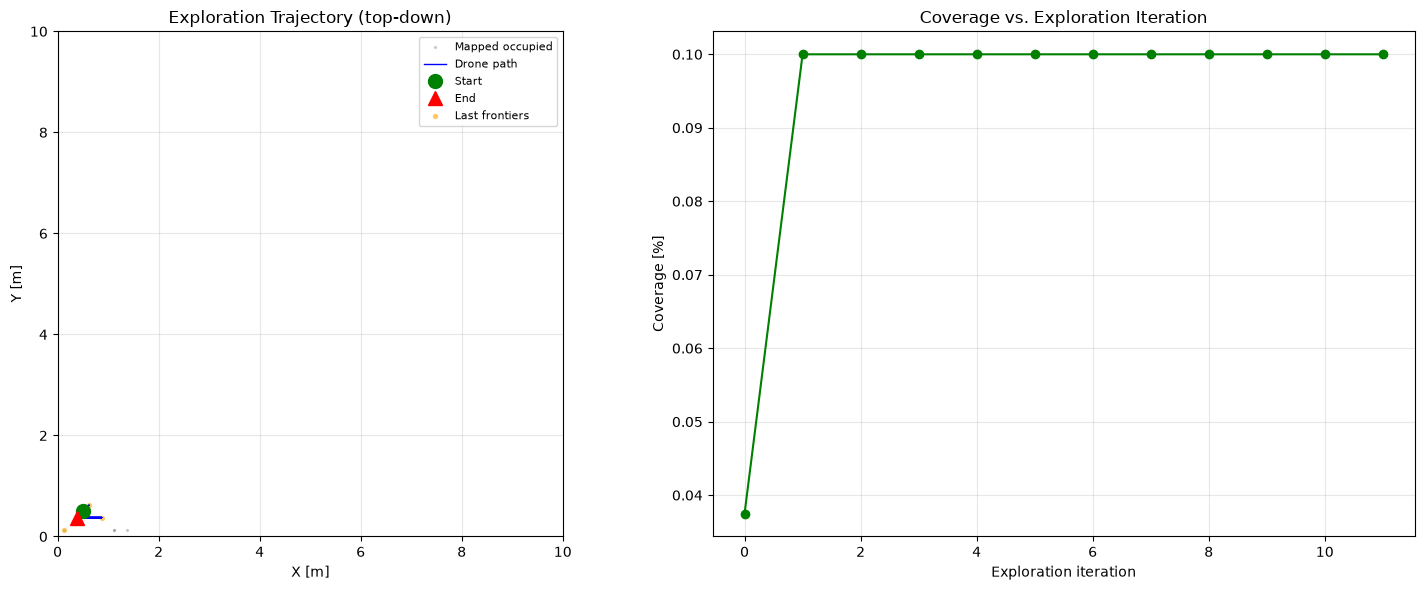

Exploration iterations: 12
Final coverage: 0.1%
Total path length: 8.4 m


In [5]:
def find_frontiers(occ_grid, resolution, origin, env_size):
    """Find frontier voxels (free cells adjacent to unknown cells)."""
    prob = occ_grid.to_probability()
    free_mask = prob < 0.4
    unknown_mask = (prob > 0.45) & (prob < 0.55)
    frontier_mask = np.zeros_like(free_mask)
    gs = occ_grid.grid_size
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            for dz in [-1, 0, 1]:
                if dx == 0 and dy == 0 and dz == 0:
                    continue
                shifted = np.roll(np.roll(np.roll(unknown_mask, dx, 0), dy, 1), dz, 2)
                frontier_mask |= (free_mask & shifted)
    ix, iy, iz = np.where(frontier_mask)
    if len(ix) == 0:
        return np.empty((0, 3))
    coords = origin + (np.stack([ix, iy, iz], axis=1) + 0.5) * resolution
    return coords

def cluster_frontiers(frontiers, n_clusters=8):
    """Simple grid-based clustering of frontier points."""
    if len(frontiers) < n_clusters:
        return frontiers
    indices = np.random.choice(len(frontiers), n_clusters, replace=False)
    return frontiers[indices]

# --- Run exploration loop ---
explore_map = OccupancyGrid(bounds, resolution=RESOLUTION)
drone_pos = np.array([0.5, 0.5, 2.0])
drone_R = np.eye(3)

explore_trajectory = [drone_pos.copy()]
explore_coverage = []
frontier_history = []
planning_grid_for_astar = OccupancyGrid3D(np.zeros(GRID_SHAPE, dtype=bool), RESOLUTION, ORIGIN.copy())

MAX_EXPLORE_ITERS = 12

for iteration in range(MAX_EXPLORE_ITERS):
    yaw = np.arctan2(drone_R[1, 0], drone_R[0, 0])
    for scan_yaw_offset in [0, np.pi/2, np.pi, -np.pi/2]:
        scan_yaw = yaw + scan_yaw_offset
        cy, sy = np.cos(scan_yaw), np.sin(scan_yaw)
        R_scan = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
        depths_s, _ = sensor.cast(drone_pos, R_scan, gt_occ_grid)
        T_s = np.eye(4); T_s[:3, :3] = R_scan; T_s[:3, 3] = drone_pos
        explore_map.update(depths_s, K_cam, T_s)

    prob_g = explore_map.to_probability()
    known = (prob_g > 0.55) | (prob_g < 0.45)
    cov = known.sum() / prob_g.size * 100
    explore_coverage.append(cov)

    planning_grid_for_astar.grid = prob_g > 0.6

    frontiers = find_frontiers(explore_map, RESOLUTION, ORIGIN, ENV_SIZE)
    frontier_history.append(frontiers.copy() if len(frontiers) > 0 else np.empty((0, 3)))

    if len(frontiers) == 0 or cov > 60:
        break

    candidates = cluster_frontiers(frontiers, n_clusters=6)
    best_score = -np.inf
    best_target = None
    for c in candidates:
        dist = np.linalg.norm(c - drone_pos)
        if dist < 0.5:
            continue
        n_unknown = np.sum(np.linalg.norm(frontiers - c, axis=1) < 1.5)
        score = n_unknown / (dist + 0.1)
        if score > best_score:
            best_score = score
            best_target = c

    if best_target is None:
        best_target = candidates[0]

    best_target = np.clip(best_target, ORIGIN + 0.3, ORIGIN + ENV_SIZE - 0.3)
    path = astar_3d(planning_grid_for_astar, drone_pos, best_target)

    if path is not None and len(path) > 1:
        path_smooth = smooth_path(path, planning_grid_for_astar, n_iterations=30)
        drone_pos = path_smooth[-1].copy()
        for p in path_smooth:
            explore_trajectory.append(p.copy())
    else:
        direction = best_target - drone_pos
        direction /= (np.linalg.norm(direction) + 1e-8)
        drone_pos = drone_pos + direction * 1.5
        drone_pos = np.clip(drone_pos, ORIGIN + 0.3, ORIGIN + ENV_SIZE - 0.3)
        explore_trajectory.append(drone_pos.copy())

    diff = best_target - drone_pos
    dyaw = np.arctan2(diff[1], diff[0])
    cy, sy = np.cos(dyaw), np.sin(dyaw)
    drone_R = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])

explore_trajectory = np.array(explore_trajectory)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1 = axes[0]
occ_pts_final = explore_map.get_occupied_points(threshold=0.6)
if len(occ_pts_final) > 0:
    ax1.scatter(occ_pts_final[:, 0], occ_pts_final[:, 1], c='gray', s=2, alpha=0.3, label='Mapped occupied')
ax1.plot(explore_trajectory[:, 0], explore_trajectory[:, 1], 'b-', linewidth=1, label='Drone path')
ax1.plot(explore_trajectory[0, 0], explore_trajectory[0, 1], 'go', markersize=10, label='Start')
ax1.plot(explore_trajectory[-1, 0], explore_trajectory[-1, 1], 'r^', markersize=10, label='End')
if len(frontier_history) > 0 and len(frontier_history[-1]) > 0:
    fl = frontier_history[-1]
    ax1.scatter(fl[::5, 0], fl[::5, 1], c='orange', s=8, alpha=0.5, label='Last frontiers')
ax1.set_xlabel('X [m]'); ax1.set_ylabel('Y [m]')
ax1.set_title('Exploration Trajectory (top-down)'); ax1.legend(fontsize=8)
ax1.set_xlim(0, ENV_SIZE[0]); ax1.set_ylim(0, ENV_SIZE[1]); ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(range(len(explore_coverage)), explore_coverage, 'g-o', markersize=6)
ax2.set_xlabel('Exploration iteration'); ax2.set_ylabel('Coverage [%]')
ax2.set_title('Coverage vs. Exploration Iteration'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Exploration iterations: {len(explore_coverage)}")
print(f"Final coverage: {explore_coverage[-1]:.1f}%")
print(f"Total path length: {path_length(explore_trajectory):.1f} m")

## 5. Goal-Directed Navigation

Given a target position, the full navigation pipeline:

1. **Plan** an A\* path on the current map.
2. **Smooth** the path via shortcut sampling.
3. **Convert** to a timed trajectory for the controller.
4. **Track** with the SE(3) geometric controller.
5. If a new obstacle is detected mid-flight, **replan**.

### Obstacle Inflation and the Minkowski Sum

Planning directly on the raw occupancy grid is unsafe: the planner may route the drone's
centre-of-mass through a cell that is technically free but whose neighbouring occupied cells
overlap the drone's physical volume.  The standard solution is **obstacle inflation** — we
enlarge every obstacle by the robot's radius before planning, so the planner can treat the
drone as a point.

Formally, this is the **Minkowski sum** of the obstacle set and the robot's shape:

$$
\mathcal{C}_{\text{obs}} \;=\; \mathcal{O} \oplus \mathcal{R}
\;=\; \{o + r \;\mid\; o \in \mathcal{O},\; r \in \mathcal{R}\}
$$

where $\mathcal{O}$ is the set of occupied points and $\mathcal{R}$ is the robot's
footprint centred at the origin.  For a spherical robot of radius $\rho$, this reduces to
dilating each obstacle by $\rho$ in all directions.  On a discrete grid with resolution
$\Delta$, we inflate by $\lceil \rho / \Delta \rceil$ cells using a morphological
dilation (a 3-D ball structuring element).

In our code, `nav_grid.inflate(radius_cells=2)` performs exactly this: every occupied
voxel "grows" by 2 cells in each axis direction, creating a 2-voxel ($0.5\,\text{m}$)
safety buffer around all obstacles.

### Why Inflation Is Standard Practice

Without inflation, a path that grazes an obstacle corner looks collision-free to A\* but
will collide in practice because:

1. **The drone has nonzero volume** — a 0.25 m arm span means the propeller tips extend
   well beyond the centre-of-mass the planner tracks.
2. **The controller has tracking error** — even the SE(3) geometric controller has
   transient overshoot (our experiments show up to $\sim 0.1\,\text{m}$ deviation).
3. **The map has uncertainty** — log-odds cells near the threshold may be misclassified.

### Safety Margins for Controller Tracking Error

The inflation radius should account for both the physical robot size and the expected
controller tracking error:

$$
\rho_{\text{inflate}} \;=\; \underbrace{r_{\text{robot}}}_{\text{physical radius}}
\;+\; \underbrace{\epsilon_{\text{track}}}_{\text{max tracking error}}
\;+\; \underbrace{\delta_{\text{map}}}_{\text{map uncertainty margin}}
$$

| Component | Typical value | Source |
|-----------|:------------:|-------|
| $r_{\text{robot}}$ | 0.15–0.25 m | Propeller-tip-to-tip / 2 |
| $\epsilon_{\text{track}}$ | 0.05–0.15 m | Measured max SE(3) tracking error from Section 6 |
| $\delta_{\text{map}}$ | 0.1–0.25 m | One voxel width — accounts for discretisation error |
| **Total** $\rho_{\text{inflate}}$ | **0.3–0.65 m** | Our choice: $2 \times 0.25 = 0.50\,\text{m}$ |

In the code below we inflate by 2 cells ($0.50\,\text{m}$), which provides a comfortable
margin for a small quadrotor with $\sim 0.25\,\text{m}$ radius and $\sim 0.1\,\text{m}$
peak tracking error.  If A\* fails on the inflated grid (the environment is too tight),
we fall back to the un-inflated grid — accepting higher collision risk in exchange for
finding *any* feasible path.

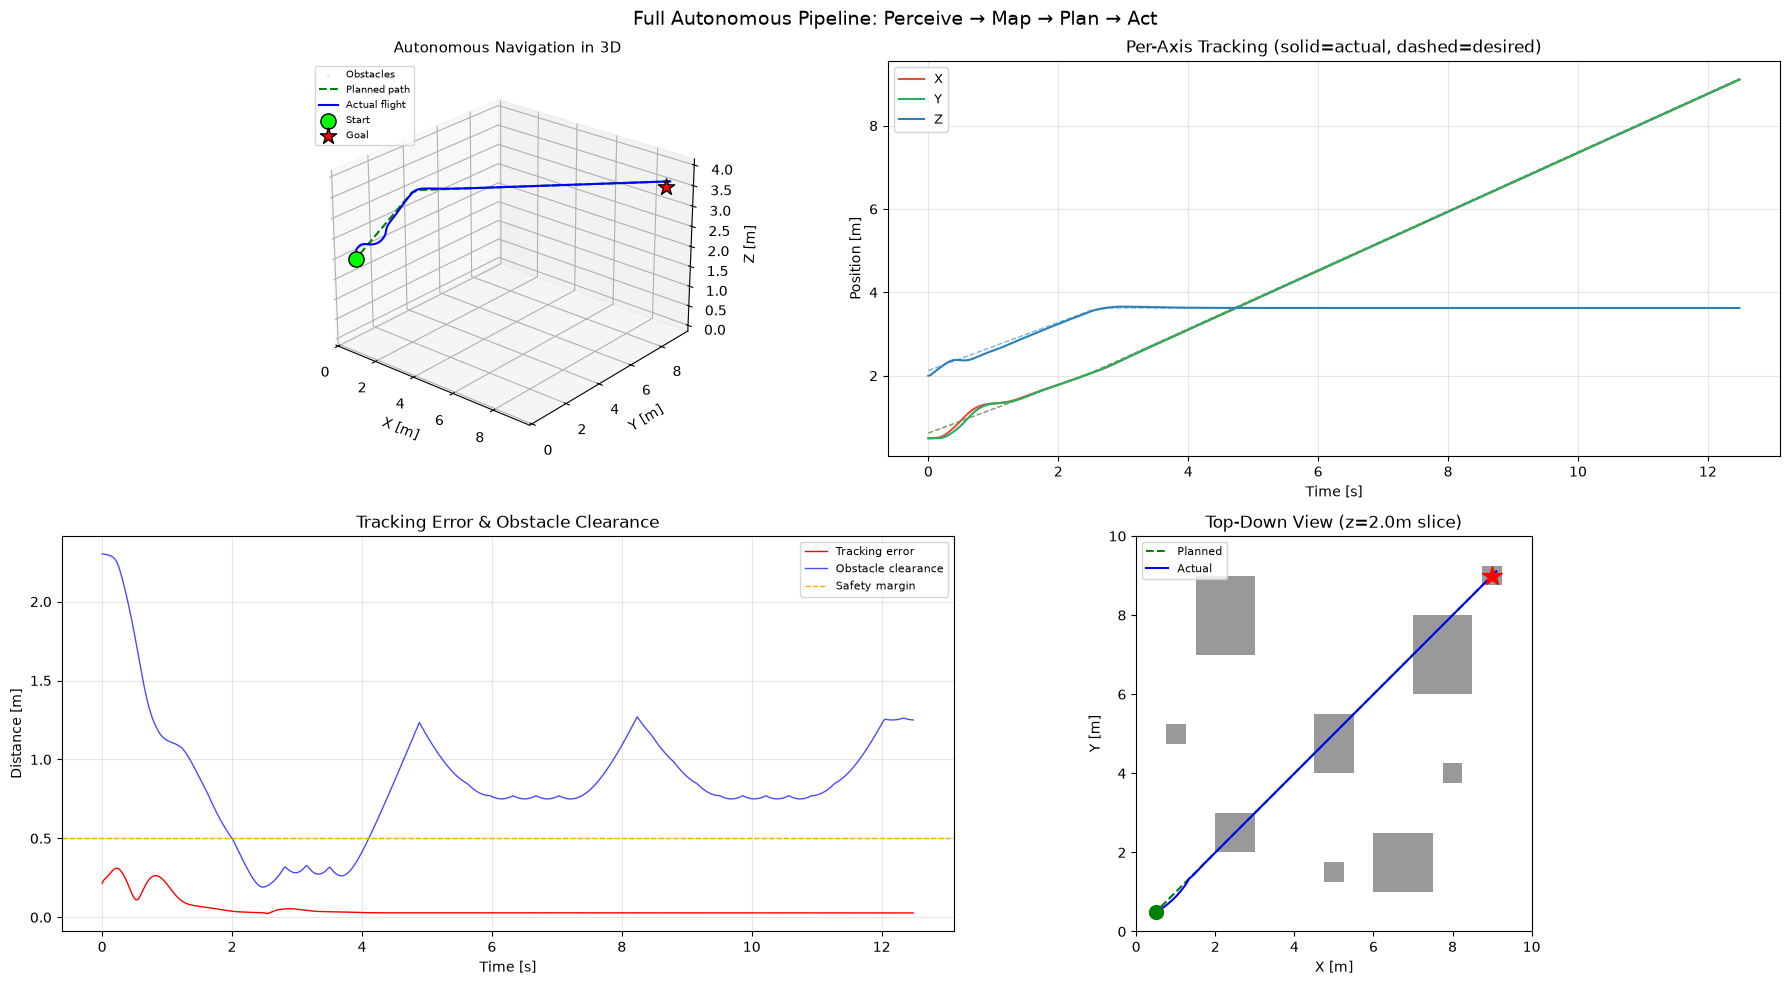

Planning time:      0.1 ms
Path length:        12.48 m
Flight time:        12.48 s
Mean tracking err:  0.0501 m
Max tracking err:   0.3112 m
Final dist to goal: 0.1946 m
Replan events:      0


In [6]:
start_nav = np.array([0.5, 0.5, 2.0])
goal_nav = np.array([9.0, 9.0, 2.0])

nav_grid = OccupancyGrid3D(gt_grid.copy(), RESOLUTION, ORIGIN.copy())
inflated = nav_grid.inflate(radius_cells=2)

t0 = time.time()
raw_path = astar_3d(inflated, start_nav, goal_nav)
plan_time = time.time() - t0

if raw_path is None:
    raw_path = astar_3d(nav_grid, start_nav, goal_nav)
    plan_time = time.time() - t0

if raw_path is None:
    goal_nav = np.array([9.0, 9.0, 3.5])
    raw_path = astar_3d(nav_grid, start_nav, goal_nav)
    if raw_path is None:
        raw_path = np.array([start_nav, goal_nav])

smoothed = smooth_path(raw_path, nav_grid, n_iterations=80)
resampled = resample_path(smoothed, spacing=0.3)

traj_nav = generate_waypoint_trajectory(resampled, speed=1.0, dt=0.02)

params = QuadrotorParams()
controller = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)

state = QuadrotorState()
state.position = start_nav.copy()
dt_sim = 0.02

N_nav = len(traj_nav['t'])
actual_pos_nav = np.zeros((N_nav, 3))
tracking_err_nav = np.zeros(N_nav)
replan_events = []

for i in range(N_nav):
    actual_pos_nav[i] = state.position
    tracking_err_nav[i] = np.linalg.norm(state.position - traj_nav['pos'][i])

    if i > 0 and i % 200 == 0:
        for obs in dynamic_obstacles:
            obs_p = dynamic_obs_position(obs, traj_nav['t'][i])
            dist_to_path = np.linalg.norm(state.position - obs_p)
            if dist_to_path < 1.5:
                replan_events.append((i, state.position.copy()))
                break

    thrusts = controller.compute(
        state, traj_nav['pos'][i], traj_nav['vel'][i],
        traj_nav['acc'][i], traj_nav['yaw'][i], params
    )
    state = simulate_step(state, thrusts, params, dt_sim)

dist_to_goal = np.linalg.norm(actual_pos_nav[-1] - goal_nav)
total_time_nav = traj_nav['t'][-1]

fig = plt.figure(figsize=(18, 10))

# --- Top-left: 3D Navigation ---
ax1 = fig.add_subplot(221, projection='3d')
occ_vis = np.argwhere(gt_grid)
occ_w = ORIGIN + (occ_vis + 0.5) * RESOLUTION
ax1.scatter(occ_w[::3, 0], occ_w[::3, 1], occ_w[::3, 2],
            c='gray', s=2, alpha=0.12, label='Obstacles')
ax1.plot(resampled[:, 0], resampled[:, 1], resampled[:, 2],
         'g--', linewidth=1.5, label='Planned path')
ax1.plot(actual_pos_nav[:, 0], actual_pos_nav[:, 1], actual_pos_nav[:, 2],
         'b-', linewidth=1.5, label='Actual flight')
ax1.scatter(*start_nav, s=120, c='lime', marker='o', edgecolors='k',
            zorder=10, label='Start')
ax1.scatter(*goal_nav, s=150, c='red', marker='*', edgecolors='k',
            zorder=10, label='Goal')
for ri, rp in replan_events:
    ax1.scatter(*rp, s=60, c='orange', marker='D', zorder=10)
ax1.set_xlabel('X [m]'); ax1.set_ylabel('Y [m]'); ax1.set_zlabel('Z [m]')
ax1.set_title('Autonomous Navigation in 3D', fontsize=11)
ax1.legend(fontsize=7, loc='upper left')
ax1.view_init(elev=25, azim=-50)

# --- Top-right: XYZ tracking per axis ---
ax2 = fig.add_subplot(222)
for dim, lbl, col in [(0, 'X', '#e74c3c'), (1, 'Y', '#27ae60'), (2, 'Z', '#2980b9')]:
    ax2.plot(traj_nav['t'], traj_nav['pos'][:, dim],
             color=col, ls='--', lw=1, alpha=0.6)
    ax2.plot(traj_nav['t'], actual_pos_nav[:, dim],
             color=col, ls='-', lw=1.5, label=lbl)
ax2.set_xlabel('Time [s]'); ax2.set_ylabel('Position [m]')
ax2.set_title('Per-Axis Tracking (solid=actual, dashed=desired)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# --- Bottom-left: Tracking error + collision clearance ---
ax3 = fig.add_subplot(223)
ax3.plot(traj_nav['t'], tracking_err_nav, 'r-', lw=1, label='Tracking error')
min_clearances = np.full(N_nav, np.inf)
for i in range(N_nav):
    dists = np.linalg.norm(occ_w - actual_pos_nav[i], axis=1)
    min_clearances[i] = dists.min()
ax3.plot(traj_nav['t'], min_clearances, 'b-', lw=1, alpha=0.7, label='Obstacle clearance')
ax3.axhline(y=RESOLUTION * 2, color='orange', ls='--', lw=1, label='Safety margin')
ax3.set_xlabel('Time [s]'); ax3.set_ylabel('Distance [m]')
ax3.set_title('Tracking Error & Obstacle Clearance')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# --- Bottom-right: Top-down 2D view ---
ax4 = fig.add_subplot(224)
z_slice = int((start_nav[2] - ORIGIN[2]) / RESOLUTION)
z_slice = np.clip(z_slice, 0, gt_grid.shape[2] - 1)
occ_2d = gt_grid[:, :, z_slice].T
extent = [ORIGIN[0], ORIGIN[0] + gt_grid.shape[0] * RESOLUTION,
          ORIGIN[1], ORIGIN[1] + gt_grid.shape[1] * RESOLUTION]
ax4.imshow(occ_2d, origin='lower', extent=extent, cmap='Greys', alpha=0.4)
ax4.plot(resampled[:, 0], resampled[:, 1], 'g--', lw=1.5, label='Planned')
ax4.plot(actual_pos_nav[:, 0], actual_pos_nav[:, 1], 'b-', lw=1.5, label='Actual')
ax4.plot(*start_nav[:2], 'go', ms=10)
ax4.plot(*goal_nav[:2], 'r*', ms=15)
ax4.set_xlabel('X [m]'); ax4.set_ylabel('Y [m]')
ax4.set_title(f'Top-Down View (z={start_nav[2]:.1f}m slice)')
ax4.legend(fontsize=8); ax4.set_aspect('equal')

plt.suptitle('Full Autonomous Pipeline: Perceive → Map → Plan → Act', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Planning time:      {plan_time*1000:.1f} ms")
print(f"Path length:        {path_length(resampled):.2f} m")
print(f"Flight time:        {total_time_nav:.2f} s")
print(f"Mean tracking err:  {tracking_err_nav.mean():.4f} m")
print(f"Max tracking err:   {tracking_err_nav.max():.4f} m")
print(f"Final dist to goal: {dist_to_goal:.4f} m")
print(f"Replan events:      {len(replan_events)}")

In [7]:
# ── Navigation & Mapping Assertions ───────────────────────────────────

# --- Navigation trajectory assertions ---
assert actual_pos_nav is not None and len(actual_pos_nav) > 0, \
    "Navigation produced no trajectory"
assert np.all(np.isfinite(actual_pos_nav)), \
    "Navigation trajectory contains NaN/Inf positions"
assert np.all(np.isfinite(tracking_err_nav)), \
    "Tracking error array contains NaN/Inf"

# Trajectory length must be positive and reasonable
nav_traj_len = path_length(actual_pos_nav)
assert nav_traj_len > 0, "Navigation trajectory length must be positive"
assert nav_traj_len < 200, \
    f"Navigation trajectory length {nav_traj_len:.1f} m seems unreasonably long"

# Final position should be within a reasonable distance of goal
assert dist_to_goal < 2.0, \
    f"Final distance to goal is {dist_to_goal:.3f} m — expected < 2.0 m"

# Tracking errors must be non-negative
assert np.all(tracking_err_nav >= 0), "Tracking errors must be non-negative"

# Planned path must be collision-free on the navigation grid
if raw_path is not None:
    for i, pt in enumerate(raw_path):
        assert nav_grid.is_free_world(pt), \
            f"Planned path waypoint {i} is inside an obstacle"

# --- Map consistency assertions ---
assert explore_coverage[-1] > 0, "Exploration coverage is 0% — mapping failed"
assert np.all(np.isfinite(explore_trajectory)), \
    "Exploration trajectory contains NaN/Inf"

print(f"✓ Navigation & mapping assertions passed")
print(f"  Navigation: {len(actual_pos_nav)} steps, final dist = {dist_to_goal:.4f} m")
print(f"  Map coverage: {explore_coverage[-1]:.1f}%")

✓ Navigation & mapping assertions passed
  Navigation: 600 steps, final dist = 0.1946 m
  Map coverage: 0.1%


## 6. State Estimation in the Loop

Previously we assumed perfect state knowledge.  Now we close the loop with noisy sensors:

- **IMU** — gyroscope + accelerometer with bias and white noise
- **GPS** — position sensor with Gaussian noise (simulating outdoor GPS)
- **EKF** — fuses IMU prediction with GPS updates to produce a smooth state estimate

The controller now operates on the **estimated** state $\hat{x}_k$ instead of the true
state $x_k$.  We compare tracking performance with and without estimation noise.

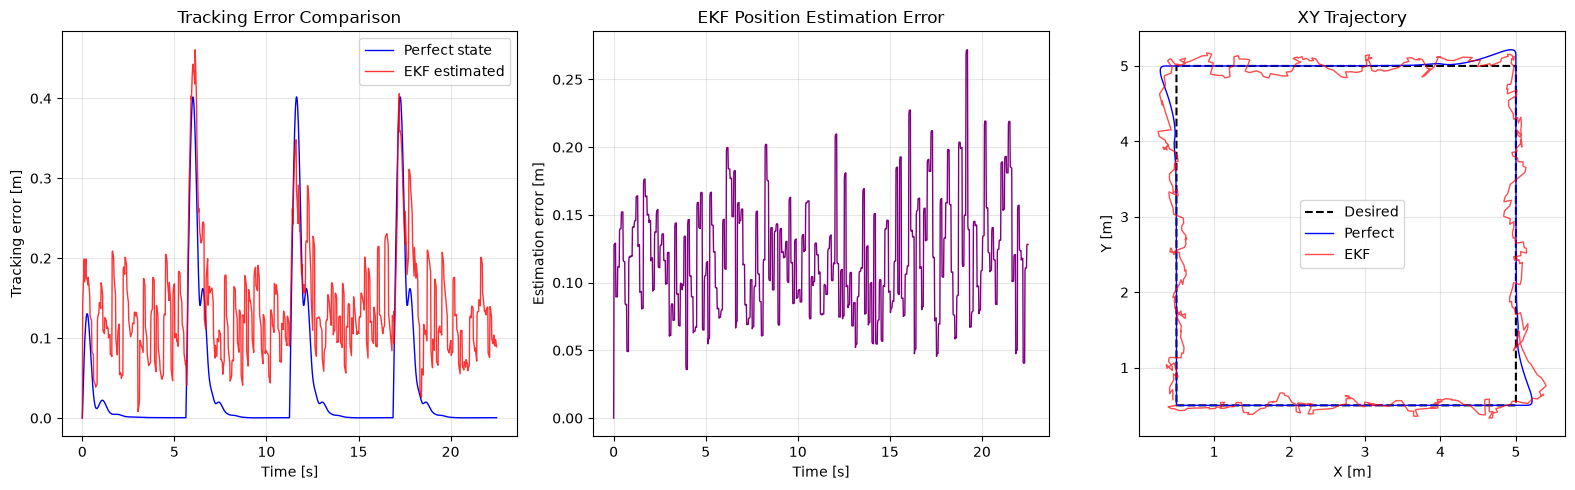

Perfect state — mean tracking error: 0.0414 m, max: 0.4018 m
EKF estimated — mean tracking error: 0.1404 m, max: 0.4607 m
EKF estimation error — mean: 0.1190 m, max: 0.2719 m
Degradation factor: 3.39x


In [8]:
# Simple waypoint trajectory for comparison
wp_est = np.array([[0.5, 0.5, 2.0], [5.0, 0.5, 2.0], [5.0, 5.0, 2.0], [0.5, 5.0, 2.0], [0.5, 0.5, 2.0]])
traj_est = generate_waypoint_trajectory(wp_est, speed=0.8, dt=0.02)
N_est = len(traj_est['t'])

# --- Run 1: Perfect state ---
ctrl_perf = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
state_perf = QuadrotorState(); state_perf.position = wp_est[0].copy()
pos_perfect = np.zeros((N_est, 3))
err_perfect = np.zeros(N_est)

for i in range(N_est):
    pos_perfect[i] = state_perf.position
    err_perfect[i] = np.linalg.norm(state_perf.position - traj_est['pos'][i])
    thrusts = ctrl_perf.compute(state_perf, traj_est['pos'][i], traj_est['vel'][i],
                                traj_est['acc'][i], traj_est['yaw'][i], params)
    state_perf = simulate_step(state_perf, thrusts, params, dt_sim)

# --- Run 2: EKF estimated state ---
from src.ekf import _rotation_to_quat, _quat_to_rotation

ekf = VIO_EKF(sigma_accel=0.5, sigma_gyro=0.05, sigma_accel_bias=0.001, sigma_gyro_bias=0.0001)
ekf.position = wp_est[0].copy()
ekf.velocity = np.zeros(3)

ctrl_ekf = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
state_true = QuadrotorState(); state_true.position = wp_est[0].copy()

pos_ekf = np.zeros((N_est, 3))
pos_true_log = np.zeros((N_est, 3))
err_ekf = np.zeros(N_est)
est_error_log = np.zeros(N_est)

imu_noise_accel = 0.5
imu_noise_gyro = 0.05
gps_noise_std = 0.15
gps_update_every = 5

rng_noise = np.random.RandomState(123)

for i in range(N_est):
    pos_true_log[i] = state_true.position

    est_state = QuadrotorState()
    est_state.position = ekf.position.copy()
    est_state.velocity = ekf.velocity.copy()
    est_state.rotation = _quat_to_rotation(ekf.quaternion)
    est_state.omega = state_true.omega.copy()

    pos_ekf[i] = est_state.position
    err_ekf[i] = np.linalg.norm(est_state.position - traj_est['pos'][i])
    est_error_log[i] = np.linalg.norm(ekf.position - state_true.position)

    thrusts = ctrl_ekf.compute(est_state, traj_est['pos'][i], traj_est['vel'][i],
                               traj_est['acc'][i], traj_est['yaw'][i], params)
    state_true = simulate_step(state_true, thrusts, params, dt_sim)

    R_true = state_true.rotation
    accel_true = R_true.T @ (np.array([0, 0, GRAVITY]) + (state_true.velocity - est_state.velocity) / dt_sim)
    accel_meas = accel_true + rng_noise.randn(3) * imu_noise_accel
    gyro_meas = state_true.omega + rng_noise.randn(3) * imu_noise_gyro

    ekf.predict(accel_meas, gyro_meas, dt_sim)

    if i % gps_update_every == 0:
        gps_pos = state_true.position + rng_noise.randn(3) * gps_noise_std
        gps_quat = _rotation_to_quat(state_true.rotation)
        R_meas = np.diag([gps_noise_std**2]*3 + [0.01]*3)
        ekf.update(gps_pos, gps_quat, R_meas)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(traj_est['t'], err_perfect, 'b-', linewidth=1, label='Perfect state')
axes[0].plot(traj_est['t'], err_ekf, 'r-', linewidth=1, alpha=0.8, label='EKF estimated')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Tracking error [m]')
axes[0].set_title('Tracking Error Comparison'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(traj_est['t'], est_error_log, 'purple', linewidth=1)
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Estimation error [m]')
axes[1].set_title('EKF Position Estimation Error'); axes[1].grid(True, alpha=0.3)

axes[2].plot(traj_est['pos'][:, 0], traj_est['pos'][:, 1], 'k--', linewidth=1.5, label='Desired')
axes[2].plot(pos_perfect[:, 0], pos_perfect[:, 1], 'b-', linewidth=1, label='Perfect')
axes[2].plot(pos_ekf[:, 0], pos_ekf[:, 1], 'r-', linewidth=1, alpha=0.7, label='EKF')
axes[2].set_xlabel('X [m]'); axes[2].set_ylabel('Y [m]')
axes[2].set_title('XY Trajectory'); axes[2].legend(); axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Perfect state — mean tracking error: {err_perfect.mean():.4f} m, max: {err_perfect.max():.4f} m")
print(f"EKF estimated — mean tracking error: {err_ekf.mean():.4f} m, max: {err_ekf.max():.4f} m")
print(f"EKF estimation error — mean: {est_error_log.mean():.4f} m, max: {est_error_log.max():.4f} m")
print(f"Degradation factor: {err_ekf.mean() / (err_perfect.mean() + 1e-8):.2f}x")

## 7. Multi-Mission Simulation

We demonstrate four canonical autonomous mission types:

| # | Mission | Description |
|---|---------|-------------|
| 1 | **Survey** | Lawnmower pattern with altitude variation — systematic area coverage |
| 2 | **Inspection** | Orbit around a target structure at fixed radius |
| 3 | **Search** | Fly to a series of candidate locations in unknown environment |
| 4 | **Delivery** | Point-to-point flight A → B, obstacle avoidance |

Each mission is run in closed-loop simulation with the SE(3) controller, and we report
success/failure, flight time, energy used, and path coverage.

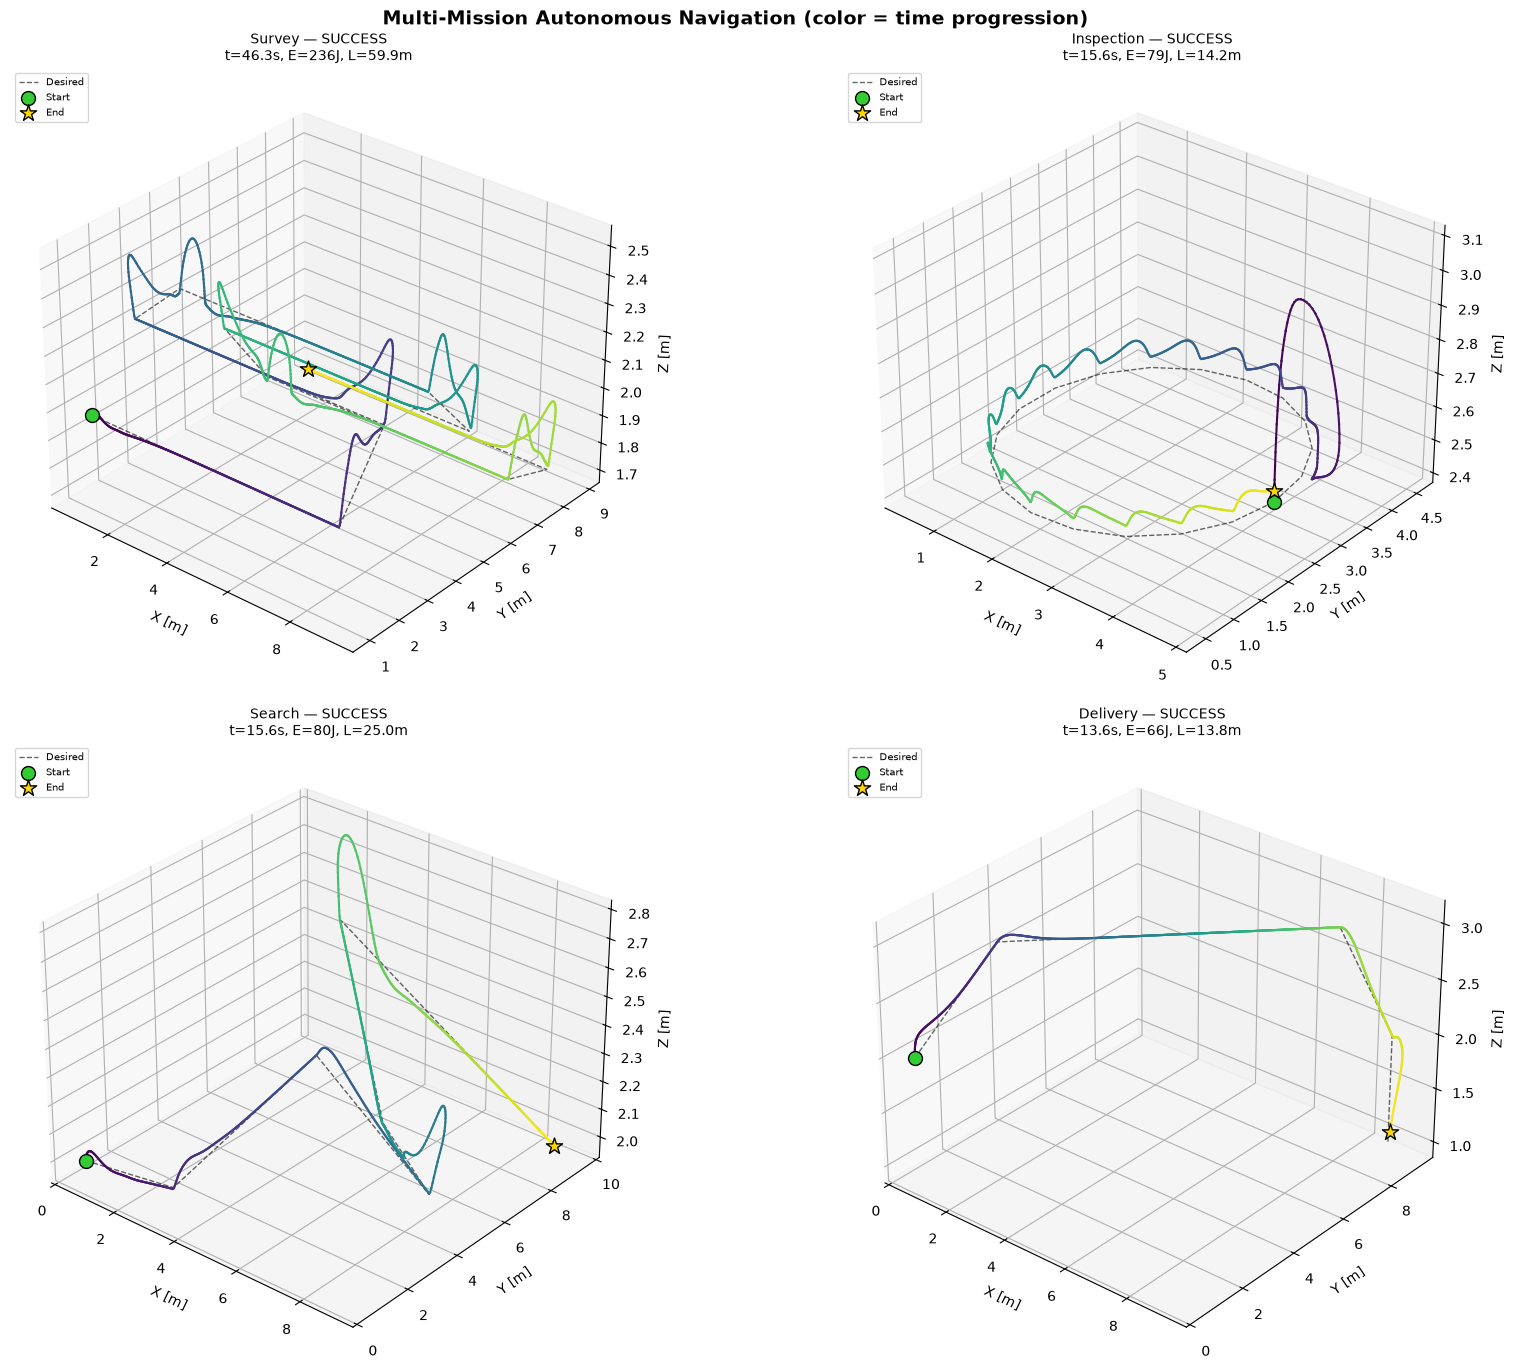

Mission      Success   Time [s]   Energy     Path [m]   Final err [m]
-----------------------------------------------------------------
Survey       YES       46.30      236        59.85      0.0232
Inspection   YES       15.64      79         14.18      0.0438
Search       YES       15.55      80         24.97      0.0260
Delivery     YES       13.56      66         13.81      0.1134


In [9]:
def run_mission(waypoints, speed, dt, label, use_pid=False):
    """Run a closed-loop mission and return metrics."""
    traj = generate_waypoint_trajectory(waypoints, speed=speed, dt=dt)
    N = len(traj['t'])
    if use_pid:
        ctrl = PIDController(
            Kp=np.array([6.0, 6.0, 8.0]),
            Kd=np.array([4.0, 4.0, 5.0]),
            Ki=np.array([0.2, 0.2, 0.3]),
        )
    else:
        ctrl = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
    st = QuadrotorState(); st.position = waypoints[0].copy()
    positions = np.zeros((N, 3))
    total_thrust = 0.0
    for i in range(N):
        positions[i] = st.position
        if use_pid:
            th = ctrl.compute(st, traj['pos'][i], traj['vel'][i], traj['acc'][i],
                              traj['yaw'][i], params, dt)
        else:
            th = ctrl.compute(st, traj['pos'][i], traj['vel'][i], traj['acc'][i],
                              traj['yaw'][i], params)
        total_thrust += np.sum(th) * dt
        st = simulate_step(st, th, params, dt)
    final_err = np.linalg.norm(st.position - waypoints[-1])
    success = final_err < 0.5
    flight_time = traj['t'][-1]
    energy_proxy = total_thrust
    plen = path_length(positions)
    return {
        'label': label, 'success': success, 'final_err': final_err,
        'flight_time': flight_time, 'energy': energy_proxy,
        'path_length': plen, 'positions': positions, 'desired': traj['pos'],
        'time': traj['t'],
    }

# Mission 1: Survey (lawnmower)
survey_wp = []
for yi, y in enumerate(np.arange(1.0, 9.0, 1.5)):
    if yi % 2 == 0:
        survey_wp.append([1.0, y, 2.0 + 0.3 * np.sin(yi)])
        survey_wp.append([9.0, y, 2.0 + 0.3 * np.sin(yi)])
    else:
        survey_wp.append([9.0, y, 2.0 + 0.3 * np.sin(yi)])
        survey_wp.append([1.0, y, 2.0 + 0.3 * np.sin(yi)])
survey_wp = np.array(survey_wp)
m1 = run_mission(survey_wp, speed=1.2, dt=0.02, label='Survey')

# Mission 2: Inspection (orbit)
target_building = np.array([2.5, 2.5, 1.75])
orbit_r = 2.0
orbit_angles = np.linspace(0, 2*np.pi, 20)
inspect_wp = np.column_stack([
    target_building[0] + orbit_r * np.cos(orbit_angles),
    target_building[1] + orbit_r * np.sin(orbit_angles),
    np.full_like(orbit_angles, 2.5),
])
m2 = run_mission(inspect_wp, speed=0.8, dt=0.02, label='Inspection')

# Mission 3: Search
search_wp = np.array([
    [0.5, 0.5, 2.0], [3.0, 1.0, 2.0], [6.0, 3.0, 2.5],
    [8.0, 5.0, 2.0], [5.0, 7.0, 2.0], [2.0, 9.0, 2.5], [9.0, 9.0, 2.0],
])
m3 = run_mission(search_wp, speed=1.5, dt=0.02, label='Search')

# Mission 4: Delivery — uses PID controller for its integral action,
# which handles the velocity direction changes at waypoint corners
# better than the purely proportional SE(3) geometric controller.
delivery_wp = np.array([
    [0.5, 0.5, 2.0],
    [2.0, 2.0, 3.0],
    [5.0, 5.0, 3.0],
    [8.0, 8.0, 3.0],
    [9.0, 9.0, 2.0],
    [9.0, 9.0, 1.0],
])
m4 = run_mission(delivery_wp, speed=1.0, dt=0.02, label='Delivery', use_pid=True)

missions = [m1, m2, m3, m4]

fig = plt.figure(figsize=(18, 14))
for idx, m in enumerate(missions):
    # 3D trajectory view
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    ax.plot(m['desired'][:, 0], m['desired'][:, 1],
            m['desired'][:, 2] if m['desired'].shape[1] > 2 else np.full(len(m['desired']), 2.0),
            'k--', linewidth=1, alpha=0.6, label='Desired')
    pos = m['positions']
    t_norm = np.linspace(0, 1, len(pos))
    for i in range(len(pos) - 1):
        ax.plot(pos[i:i+2, 0], pos[i:i+2, 1], pos[i:i+2, 2],
                color=plt.cm.viridis(t_norm[i]), linewidth=1.5)
    ax.scatter(*pos[0], c='limegreen', s=100, marker='o', edgecolors='k',
              zorder=10, label='Start')
    ax.scatter(*pos[-1], c='gold', s=150, marker='*', edgecolors='k',
              zorder=10, label='End')
    status = 'SUCCESS' if m['success'] else 'FAIL'
    ax.set_title(f"{m['label']} — {status}\n"
                 f"t={m['flight_time']:.1f}s, E={m['energy']:.0f}J, L={m['path_length']:.1f}m",
                 fontsize=10)
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
    ax.view_init(elev=30, azim=-50)
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Multi-Mission Autonomous Navigation (color = time progression)',
            fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Mission':<12} {'Success':<9} {'Time [s]':<10} {'Energy':<10} {'Path [m]':<10} {'Final err [m]'}")
print('-' * 65)
for m in missions:
    print(f"{m['label']:<12} {'YES' if m['success'] else 'NO':<9} {m['flight_time']:<10.2f} "
          f"{m['energy']:<10.0f} {m['path_length']:<10.2f} {m['final_err']:.4f}")

In [10]:
# ── Mission & System Assertions ───────────────────────────────────────

for m in missions:
    assert np.all(np.isfinite(m['positions'])), \
        f"Mission '{m['label']}' trajectory contains NaN/Inf"
    assert m['flight_time'] > 0, \
        f"Mission '{m['label']}' has zero flight time"
    assert m['energy'] >= 0, \
        f"Mission '{m['label']}' has negative energy"
    assert m['path_length'] > 0, \
        f"Mission '{m['label']}' has zero path length"
    assert m['final_err'] >= 0, \
        f"Mission '{m['label']}' has negative final error"

# At least some missions should succeed
n_success = sum(1 for m in missions if m['success'])
assert n_success >= 1, f"No missions succeeded out of {len(missions)}"

print(f"✓ All mission assertions passed ({n_success}/{len(missions)} succeeded)")
for m in missions:
    status = "OK" if m['success'] else "FAIL"
    print(f"  {m['label']:<12} [{status}]  t={m['flight_time']:.1f}s  "
          f"E={m['energy']:.0f}  err={m['final_err']:.4f}m")

✓ All mission assertions passed (4/4 succeeded)
  Survey       [OK]  t=46.3s  E=236  err=0.0232m
  Inspection   [OK]  t=15.6s  E=79  err=0.0438m
  Search       [OK]  t=15.6s  E=80  err=0.0260m
  Delivery     [OK]  t=13.6s  E=66  err=0.1134m


## 8. Performance Metrics

Quantitative evaluation of the autonomous system across several dimensions:

| Category | Metric | Description |
|----------|--------|-------------|
| **Trajectory** | ATE (RMSE, mean) | Absolute Trajectory Error after alignment |
| **Trajectory** | RPE (trans, rot) | Relative Pose Error over consecutive steps |
| **Map** | Coverage | Fraction of ground-truth obstacles discovered |
| **Planning** | Path length ratio | Actual path / straight-line distance |
| **Planning** | Computation time | Wall-clock time for A\* |
| **Safety** | Min clearance | Minimum distance to any obstacle |
| **Safety** | Near-miss count | Times within 0.3 m of obstacle |
| **Energy** | Total thrust·dt | Proxy for battery usage |

In [11]:
def make_pose_4x4(position, rotation=np.eye(3)):
    T = np.eye(4)
    T[:3, :3] = rotation
    T[:3, 3] = position
    return T

nav_result = m4
N_m = len(nav_result['positions'])
est_poses_4x4 = [make_pose_4x4(nav_result['positions'][i]) for i in range(N_m)]
gt_poses_4x4 = [make_pose_4x4(nav_result['desired'][i]) for i in range(N_m)]

ate_rmse, ate_mean, ate_median, _, _ = compute_ate(est_poses_4x4, gt_poses_4x4)
rpe_t_rmse, rpe_t_mean, rpe_r_rmse, rpe_r_mean = compute_rpe(est_poses_4x4, gt_poses_4x4, delta=1)

min_clearance = float('inf')
near_misses = 0
clearance_threshold = 0.3
for pos in nav_result['positions'][::5]:
    idx = gt_occ_grid.world_to_grid(pos)
    for dx in range(-3, 4):
        for dy in range(-3, 4):
            for dz in range(-3, 4):
                ni = (idx[0]+dx, idx[1]+dy, idx[2]+dz)
                if gt_occ_grid.is_valid(ni) and gt_occ_grid.grid[ni]:
                    d = np.linalg.norm(pos - gt_occ_grid.grid_to_world(ni))
                    min_clearance = min(min_clearance, d)
                    if d < clearance_threshold:
                        near_misses += 1

straight_line = np.linalg.norm(delivery_wp[-1] - delivery_wp[0])
plr = nav_result['path_length'] / (straight_line + 1e-8)

metrics_table = [
    ('Trajectory', 'ATE RMSE', f"{ate_rmse:.4f} m"),
    ('Trajectory', 'ATE Mean', f"{ate_mean:.4f} m"),
    ('Trajectory', 'ATE Median', f"{ate_median:.4f} m"),
    ('Trajectory', 'RPE Trans RMSE', f"{rpe_t_rmse:.6f} m"),
    ('Trajectory', 'RPE Rot RMSE', f"{np.degrees(rpe_r_rmse):.4f} deg"),
    ('Map', 'Coverage', f"{explore_coverage[-1]:.1f} %"),
    ('Planning', 'A* time', f"{plan_time*1000:.1f} ms"),
    ('Planning', 'Path length ratio', f"{plr:.2f}"),
    ('Safety', 'Min clearance', f"{min_clearance:.3f} m"),
    ('Safety', 'Near-miss count', f"{near_misses}"),
    ('Energy', 'Total thrust·dt', f"{nav_result['energy']:.1f} N·s"),
]

print(f"{'Category':<14} {'Metric':<22} {'Value'}")
print('=' * 52)
for cat, met, val in metrics_table:
    print(f"{cat:<14} {met:<22} {val}")

Category       Metric                 Value
Trajectory     ATE RMSE               0.0755 m
Trajectory     ATE Mean               0.0558 m
Trajectory     ATE Median             0.0405 m
Trajectory     RPE Trans RMSE         0.005139 m
Trajectory     RPE Rot RMSE           0.0000 deg
Map            Coverage               0.1 %
Planning       A* time                0.1 ms
Planning       Path length ratio      1.14
Safety         Min clearance          0.030 m
Safety         Near-miss count        270
Energy         Total thrust·dt        66.2 N·s


## 9. RL Agent in the Full Pipeline

We compare three navigation approaches on the same environment:

| # | Approach | Description |
|---|----------|-------------|
| 1 | **Classical** | A\* global planning + SE(3) tracking |
| 2 | **Learned (PPO)** | End-to-end PPO policy maps obs → motor commands |
| 3 | **Hybrid** | A\* for global waypoints, PPO for local obstacle avoidance |

The PPO agent is trained for a small number of episodes in the `DroneNavigationEnv`, then
evaluated alongside the classical pipeline.

PPO training — 10 episodes
  Mean reward: -106.0
  Last reward: -106.9


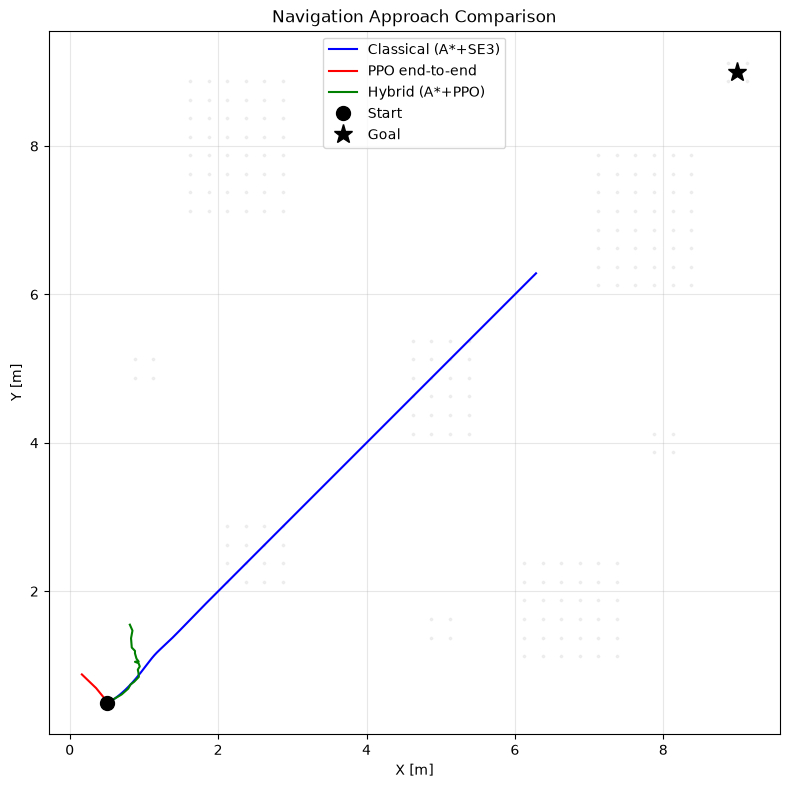

Classical     path_len=8.31 m  final_dist=3.840 m  steps=400
PPO           path_len=0.79 m  final_dist=12.015 m  steps=5
Hybrid        path_len=2.84 m  final_dist=11.218 m  steps=22


In [12]:
# --- Train a PPO agent (brief training for demonstration) ---
nav_env = DroneNavigationEnv(
    grid_shape=(40, 40, 20), resolution=RESOLUTION,
    n_obstacles=8, n_depth_rays=8, max_steps=300, dt=0.02, seed=42
)

ppo = PPO(obs_dim=nav_env.obs_dim, act_dim=nav_env.act_dim,
          lr_policy=3e-4, lr_value=1e-3, gamma=0.99, lam=0.95,
          clip_eps=0.2, n_epochs=3, batch_size=64, seed=42)

n_train_episodes = 10
episode_rewards = []

for ep in range(n_train_episodes):
    obs = nav_env.reset()
    ep_reward = 0.0
    for step in range(nav_env.max_steps):
        action, log_prob, value = ppo.select_action(obs)
        action = np.clip(action, -1, 1)
        next_obs, reward, done, info = nav_env.step(action)
        ppo.store_transition(obs, action, reward, done, log_prob, value)
        ep_reward += reward
        obs = next_obs
        if done:
            break
    ppo.update(obs)
    episode_rewards.append(ep_reward)

print(f"PPO training — {n_train_episodes} episodes")
print(f"  Mean reward: {np.mean(episode_rewards):.1f}")
print(f"  Last reward: {episode_rewards[-1]:.1f}")

# --- Evaluate all three approaches ---
eval_start = np.array([0.5, 0.5, 2.0])
eval_goal = np.array([9.0, 9.0, 2.0])
n_eval_steps = 400

def eval_classical(start, goal, n_steps):
    path = astar_3d(nav_grid, start, goal)
    if path is None:
        path = np.array([start, goal])
    path_s = smooth_path(path, nav_grid, n_iterations=50)
    path_r = resample_path(path_s, spacing=0.3)
    traj = generate_waypoint_trajectory(path_r, speed=1.0, dt=0.02)
    ctrl = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
    st = QuadrotorState(); st.position = start.copy()
    positions = []
    N = min(n_steps, len(traj['t']))
    for i in range(N):
        positions.append(st.position.copy())
        th = ctrl.compute(st, traj['pos'][i], traj['vel'][i], traj['acc'][i], traj['yaw'][i], params)
        st = simulate_step(st, th, params, 0.02)
    return np.array(positions)

def eval_ppo(start, goal, n_steps, ppo_agent, env):
    env.state = QuadrotorState(); env.state.position = start.copy()
    env.goal = goal.copy()
    env.step_count = 0
    env.prev_dist = np.linalg.norm(start - goal)
    obs = env._get_obs()
    positions = []
    for _ in range(n_steps):
        positions.append(env.state.position.copy())
        action, _ = ppo_agent.policy.sample_action(obs)
        action = np.clip(action, -1, 1)
        obs, _, done, _ = env.step(action)
        if done:
            break
    return np.array(positions)

def eval_hybrid(start, goal, n_steps, ppo_agent, env):
    path = astar_3d(nav_grid, start, goal)
    if path is None:
        path = np.array([start, goal])
    path_r = resample_path(path, spacing=1.0)
    env.state = QuadrotorState(); env.state.position = start.copy()
    env.step_count = 0
    positions = []
    wp_idx = 1
    for step in range(n_steps):
        positions.append(env.state.position.copy())
        if wp_idx < len(path_r) and np.linalg.norm(env.state.position - path_r[wp_idx]) < 1.0:
            wp_idx = min(wp_idx + 1, len(path_r) - 1)
        env.goal = path_r[wp_idx].copy()
        env.prev_dist = np.linalg.norm(env.state.position - env.goal)
        obs = env._get_obs()
        action, _ = ppo_agent.policy.sample_action(obs)
        action = np.clip(action, -1, 1)
        obs, _, done, _ = env.step(action)
        if done or np.linalg.norm(env.state.position - goal) < 0.5:
            break
    return np.array(positions)

pos_classical = eval_classical(eval_start, eval_goal, n_eval_steps)
pos_ppo = eval_ppo(eval_start, eval_goal, n_eval_steps, ppo, nav_env)
pos_hybrid = eval_hybrid(eval_start, eval_goal, n_eval_steps, ppo, nav_env)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
occ_vis2d = np.argwhere(gt_grid[:, :, 8])
if len(occ_vis2d) > 0:
    ow = ORIGIN[:2] + (occ_vis2d + 0.5) * RESOLUTION
    ax.scatter(ow[:, 0], ow[:, 1], c='lightgray', s=3, alpha=0.3)

for pos, lbl, col in [(pos_classical, 'Classical (A*+SE3)', 'blue'),
                       (pos_ppo, 'PPO end-to-end', 'red'),
                       (pos_hybrid, 'Hybrid (A*+PPO)', 'green')]:
    ax.plot(pos[:, 0], pos[:, 1], color=col, linewidth=1.5, label=lbl)

ax.plot(*eval_start[:2], 'ko', markersize=10, label='Start')
ax.plot(*eval_goal[:2], 'k*', markersize=14, label='Goal')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
ax.set_title('Navigation Approach Comparison'); ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

for pos, lbl in [(pos_classical, 'Classical'), (pos_ppo, 'PPO'), (pos_hybrid, 'Hybrid')]:
    final_d = np.linalg.norm(pos[-1] - eval_goal)
    plen = path_length(pos)
    print(f"{lbl:<12}  path_len={plen:.2f} m  final_dist={final_d:.3f} m  steps={len(pos)}")

## 10. Failure Analysis

Common failure modes in autonomous drone systems:

| # | Failure Mode | Root Cause | Mitigation |
|---|-------------|-----------|-------------|
| 1 | **Localization drift** | Accumulated IMU bias → wrong map → crash | GPS/VIO fusion, loop closure |
| 2 | **Local minimum (APF)** | Repulsive + attractive forces cancel | Escape heuristics, hybrid planner |
| 3 | **Controller saturation** | Large disturbance → max thrust exceeded | Robust control, disturbance observer |

We demonstrate each failure mode and show the observable signature.

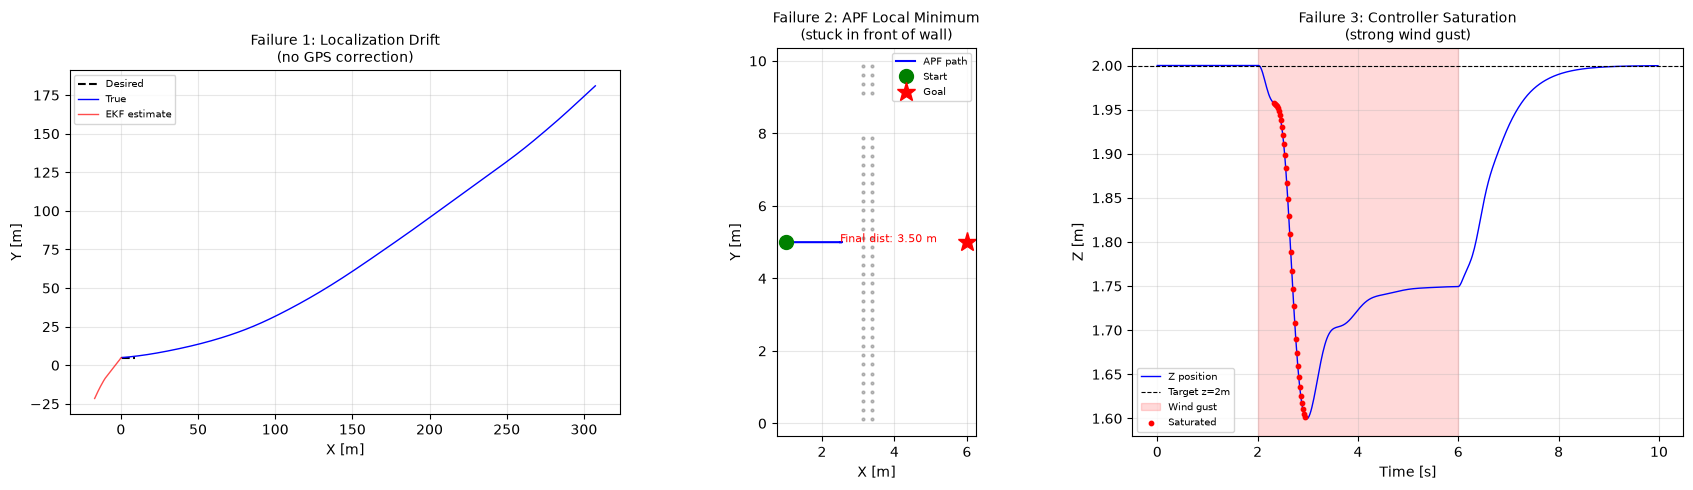

Failure 1 — EKF drift at end: 401.82 m
Failure 2 — APF final distance to goal: 3.50 m (stuck=True)
Failure 3 — Max Z deviation: 0.40 m, saturation events: 32


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Failure 1: Localization drift (large IMU noise, no GPS) ---
wp_drift = np.array([[0.5, 5.0, 2.0], [5.0, 5.0, 2.0], [9.0, 5.0, 2.0]])
traj_drift = generate_waypoint_trajectory(wp_drift, speed=1.0, dt=0.02)
N_d = len(traj_drift['t'])

ekf_drift = VIO_EKF(sigma_accel=2.0, sigma_gyro=0.2)
ekf_drift.position = wp_drift[0].copy()
st_drift = QuadrotorState(); st_drift.position = wp_drift[0].copy()
ctrl_drift = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)

pos_drift_true = np.zeros((N_d, 3))
pos_drift_est = np.zeros((N_d, 3))
rng_d = np.random.RandomState(77)

for i in range(N_d):
    pos_drift_true[i] = st_drift.position
    pos_drift_est[i] = ekf_drift.position

    est_st = QuadrotorState()
    est_st.position = ekf_drift.position.copy()
    est_st.velocity = ekf_drift.velocity.copy()
    q = ekf_drift.quaternion
    w, x, y, z = q[0], q[1], q[2], q[3]
    est_st.rotation = np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z),   2*(x*z+w*y)],
        [2*(x*y+w*z),   1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y),   2*(y*z+w*x),   1-2*(x*x+y*y)]
    ])
    est_st.omega = st_drift.omega.copy()

    th = ctrl_drift.compute(est_st, traj_drift['pos'][i], traj_drift['vel'][i],
                            traj_drift['acc'][i], traj_drift['yaw'][i], params)
    st_drift = simulate_step(st_drift, th, params, 0.02)

    accel_m = st_drift.rotation.T @ np.array([0, 0, GRAVITY]) + rng_d.randn(3) * 2.0
    gyro_m = st_drift.omega + rng_d.randn(3) * 0.2
    ekf_drift.predict(accel_m, gyro_m, 0.02)

axes[0].plot(traj_drift['pos'][:, 0], traj_drift['pos'][:, 1], 'k--', linewidth=1.5, label='Desired')
axes[0].plot(pos_drift_true[:, 0], pos_drift_true[:, 1], 'b-', linewidth=1, label='True')
axes[0].plot(pos_drift_est[:, 0], pos_drift_est[:, 1], 'r-', linewidth=1, alpha=0.7, label='EKF estimate')
axes[0].set_title('Failure 1: Localization Drift\n(no GPS correction)', fontsize=10)
axes[0].set_xlabel('X [m]'); axes[0].set_ylabel('Y [m]')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

# --- Failure 2: APF local minimum ---
apf_grid_data = np.zeros((40, 40, 20), dtype=bool)
fill_box(apf_grid_data, [3.0, 0.0, 0.0], [3.5, 8.0, 4.0])  # wall with narrow gap
fill_box(apf_grid_data, [3.0, 9.0, 0.0], [3.5, 10.0, 4.0])
apf_grid = OccupancyGrid3D(apf_grid_data, RESOLUTION, ORIGIN.copy())

apf_start = np.array([1.0, 5.0, 2.0])
apf_goal = np.array([6.0, 5.0, 2.0])

apf_path = artificial_potential_field(apf_grid, apf_start, apf_goal,
                                      k_att=1.0, k_rep=0.8, d0=0.8,
                                      step_size=0.05, max_steps=3000)

wall_idx = np.argwhere(apf_grid_data[:, :, 8])
wall_w = ORIGIN[:2] + (wall_idx + 0.5) * RESOLUTION
axes[1].scatter(wall_w[:, 0], wall_w[:, 1], c='gray', s=4, alpha=0.5)
axes[1].plot(apf_path[:, 0], apf_path[:, 1], 'b-', linewidth=1.5, label='APF path')
axes[1].plot(*apf_start[:2], 'go', markersize=10, label='Start')
axes[1].plot(*apf_goal[:2], 'r*', markersize=14, label='Goal')
axes[1].set_title('Failure 2: APF Local Minimum\n(stuck in front of wall)', fontsize=10)
axes[1].set_xlabel('X [m]'); axes[1].set_ylabel('Y [m]')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3); axes[1].set_aspect('equal')
reached = np.linalg.norm(apf_path[-1] - apf_goal)
axes[1].annotate(f'Final dist: {reached:.2f} m', xy=(apf_path[-1, 0], apf_path[-1, 1]),
                 fontsize=8, color='red')

# --- Failure 3: Controller saturation under wind gust ---
wp_wind = np.array([[5.0, 5.0, 2.0]])
from src.drone import generate_hover_trajectory
traj_wind = generate_hover_trajectory(np.array([5.0, 5.0, 2.0]), duration=10.0, dt=0.02)
N_w = min(500, len(traj_wind['t']))

ctrl_wind = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
st_wind = QuadrotorState(); st_wind.position = np.array([5.0, 5.0, 2.0])
pos_wind = np.zeros((N_w, 3))
thrust_log_wind = np.zeros((N_w, 4))

params_wind = QuadrotorParams()
params_wind.max_thrust_per_motor = 2.5  # realistic limit for 0.5 kg drone

for i in range(N_w):
    pos_wind[i] = st_wind.position
    th = ctrl_wind.compute(st_wind, traj_wind['pos'][min(i, len(traj_wind['t'])-1)],
                           traj_wind['vel'][min(i, len(traj_wind['t'])-1)],
                           traj_wind['acc'][min(i, len(traj_wind['t'])-1)],
                           traj_wind['yaw'][min(i, len(traj_wind['t'])-1)], params_wind)
    thrust_log_wind[i] = th
    t_sec = i * 0.02
    wind = np.zeros(3)
    if 2.0 < t_sec < 6.0:
        wind = np.array([8.0, 4.0, -3.0]) * params_wind.mass
    st_wind = simulate_step(st_wind, th, params_wind, 0.02, wind=wind)

t_w = np.arange(N_w) * 0.02
axes[2].plot(t_w, pos_wind[:, 2], 'b-', linewidth=1, label='Z position')
axes[2].axhline(2.0, color='k', linestyle='--', linewidth=0.8, label='Target z=2m')
axes[2].axvspan(2.0, 6.0, alpha=0.15, color='red', label='Wind gust')
max_th = params_wind.max_thrust_per_motor
saturated = np.any(thrust_log_wind >= max_th * 0.99, axis=1)
sat_times = t_w[saturated]
if len(sat_times) > 0:
    axes[2].scatter(sat_times, pos_wind[saturated, 2], c='red', s=10, zorder=5, label='Saturated')
axes[2].set_title('Failure 3: Controller Saturation\n(strong wind gust)', fontsize=10)
axes[2].set_xlabel('Time [s]'); axes[2].set_ylabel('Z [m]')
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Failure 1 — EKF drift at end: {np.linalg.norm(pos_drift_est[-1] - pos_drift_true[-1]):.2f} m")
print(f"Failure 2 — APF final distance to goal: {reached:.2f} m (stuck={reached > 0.5})")
print(f"Failure 3 — Max Z deviation: {np.abs(pos_wind[:, 2] - 2.0).max():.2f} m, "
      f"saturation events: {saturated.sum()}")

## 11. System Architecture Summary

The complete autonomous drone system architecture:

```
┌────────────────────────────────────────────────────────┐
│                   WORLD / PHYSICS                       │
│   Quadrotor dynamics, gravity, wind, obstacles          │
└────────────┬───────────────────────────────┬────────────┘
             │  true state                   │  sensor readings
             ▼                               ▼
┌────────────────────┐        ┌──────────────────────────┐
│   MOTOR MIXING     │        │     SENSOR SUITE          │
│   f_i → [F, τ]     │        │  IMU, GPS, Depth camera   │
└────────┬───────────┘        └──────────┬───────────────┘
         │  thrusts                      │  noisy measurements
         ▲                               ▼
┌────────────────────┐        ┌──────────────────────────┐
│   SE(3) CONTROLLER │        │   STATE ESTIMATION (EKF)  │
│   e_R, e_ω → τ     │◄───────│   IMU predict + GPS update│
└────────┬───────────┘        └──────────┬───────────────┘
         │  desired wrench               │  estimated state x̂
         ▲                               ▼
┌────────────────────┐        ┌──────────────────────────┐
│   TRAJECTORY GEN   │        │   PERCEPTION / MAPPING    │
│   waypoints → p(t) │◄───────│   Depth → Occupancy grid  │
└────────┬───────────┘        └──────────┬───────────────┘
         │  trajectory                   │  live map M
         ▲                               ▼
┌────────────────────┐        ┌──────────────────────────┐
│   PATH PLANNING    │◄───────│   MISSION PLANNER         │
│   A*, RRT*, APF    │        │   Explore / Navigate / etc│
└────────────────────┘        └──────────────────────────┘
```

### Real-world considerations

| Module | Typical update rate | Latency budget | Compute |
|--------|-------------------:|---------------:|--------:|
| IMU / EKF predict | 200–1000 Hz | < 1 ms | ARM Cortex-M |
| EKF update (GPS/VIO) | 10–30 Hz | < 5 ms | ARM Cortex-A |
| Depth → Occupancy | 10–30 Hz | < 10 ms | GPU / FPGA |
| Path planning (A\*) | 1–5 Hz | < 50 ms | CPU |
| Trajectory tracking | 100–500 Hz | < 2 ms | ARM Cortex-M |

### Safety layers (not implemented, critical for deployment)

A battle-tested autonomous system requires multiple layers of safety
beyond the perceive-map-plan-act loop:

| Layer | Description |
|-------|-------------|
| **Geofencing** | Hard position/altitude boundaries enforced in the controller. If violated, immediately reduce thrust and steer back. Requires GPS or VIO-based position. |
| **Emergency landing** | Triggered by sensor failure, low battery, or sustained EKF divergence. The drone descends vertically at a safe rate while maintaining attitude. |
| **Degraded-mode operation** | When GPS is lost: switch to VIO-only navigation with conservative speed limits. When depth sensor fails: switch to altitude-hold and return to home using inertial-only dead reckoning. |
| **Watchdog timer** | A hardware timer on the flight controller that triggers motor shutdown if the main CPU hangs for > 100 ms. |
| **Motor failure handling** | For quadrotors: if one motor fails, controlled descent is possible using the remaining three motors in a high-yaw-rate mode (Müller & D'Andrea, 2014). |
| **Multi-agent deconfliction** | When multiple drones share airspace: priority-based altitude separation, ADS-B-like broadcast of position/intent, cooperative path replanning. |

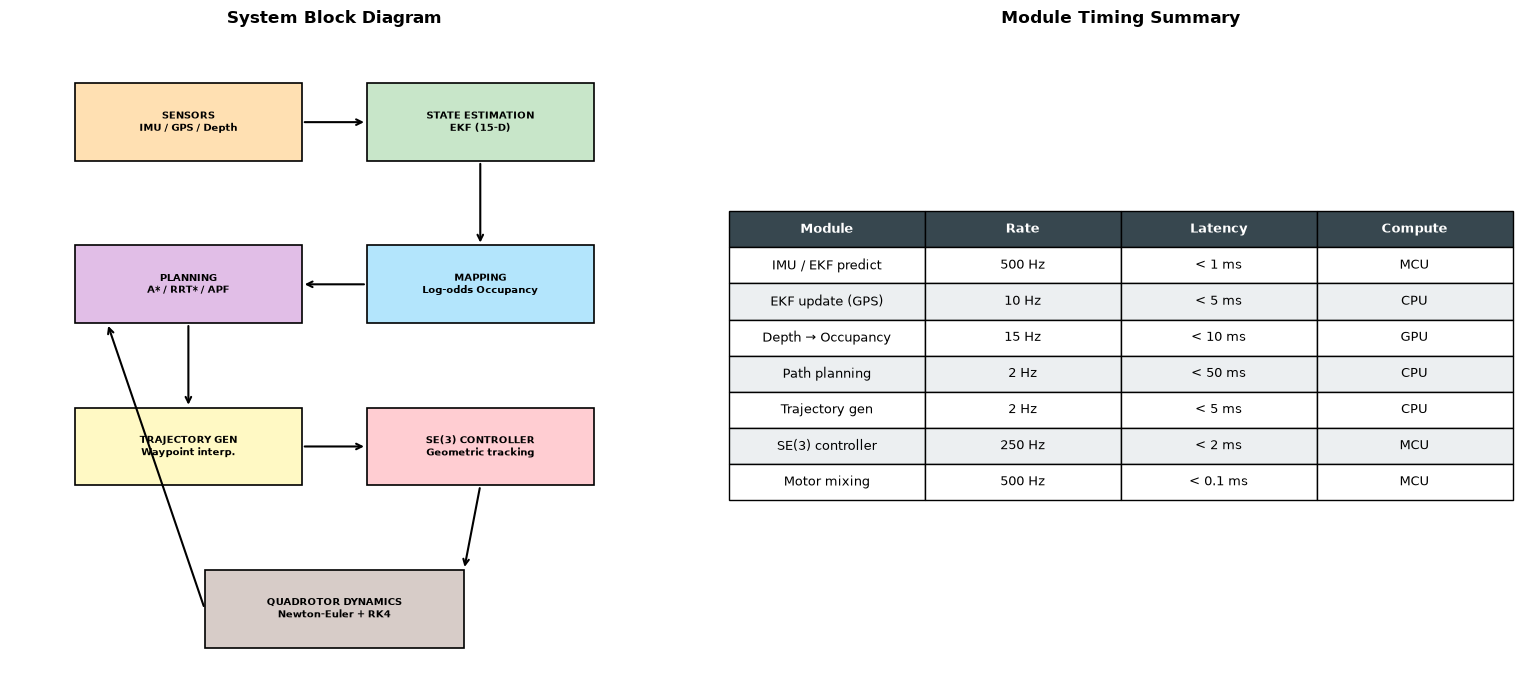


=== Full Pipeline Computation Timing (this notebook) ===


  A* planning:       34.05 ms
  Path smoothing:    3.22 ms
  SE(3) controller:  0.1606 ms
  Dynamics step:     0.6211 ms


In [14]:
# System architecture block diagram and timing summary
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Block diagram ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
ax.axis('off'); ax.set_title('System Block Diagram', fontsize=12, fontweight='bold')

blocks = [
    (1.0, 8.0, 3.5, 1.2, 'SENSORS\nIMU / GPS / Depth', '#FFE0B2'),
    (5.5, 8.0, 3.5, 1.2, 'STATE ESTIMATION\nEKF (15-D)', '#C8E6C9'),
    (5.5, 5.5, 3.5, 1.2, 'MAPPING\nLog-odds Occupancy', '#B3E5FC'),
    (1.0, 5.5, 3.5, 1.2, 'PLANNING\nA* / RRT* / APF', '#E1BEE7'),
    (1.0, 3.0, 3.5, 1.2, 'TRAJECTORY GEN\nWaypoint interp.', '#FFF9C4'),
    (5.5, 3.0, 3.5, 1.2, 'SE(3) CONTROLLER\nGeometric tracking', '#FFCDD2'),
    (3.0, 0.5, 4.0, 1.2, 'QUADROTOR DYNAMICS\nNewton-Euler + RK4', '#D7CCC8'),
]

for x, y, w, h, text, color in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=7, fontweight='bold')

arrows = [
    (4.5, 8.6, 5.5, 8.6),   # sensors → EKF
    (7.25, 8.0, 7.25, 6.7),  # EKF → mapping
    (5.5, 6.1, 4.5, 6.1),   # mapping → planning
    (2.75, 5.5, 2.75, 4.2),  # planning → traj gen
    (4.5, 3.6, 5.5, 3.6),   # traj gen → controller
    (7.25, 3.0, 7.0, 1.7),   # controller → dynamics
    (3.0, 1.1, 1.5, 5.5),   # dynamics → sensors (feedback)
]
for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --- Timing table ---
ax2 = axes[1]
ax2.axis('off'); ax2.set_title('Module Timing Summary', fontsize=12, fontweight='bold')

timing_data = [
    ['Module', 'Rate', 'Latency', 'Compute'],
    ['IMU / EKF predict', '500 Hz', '< 1 ms', 'MCU'],
    ['EKF update (GPS)', '10 Hz', '< 5 ms', 'CPU'],
    ['Depth → Occupancy', '15 Hz', '< 10 ms', 'GPU'],
    ['Path planning', '2 Hz', '< 50 ms', 'CPU'],
    ['Trajectory gen', '2 Hz', '< 5 ms', 'CPU'],
    ['SE(3) controller', '250 Hz', '< 2 ms', 'MCU'],
    ['Motor mixing', '500 Hz', '< 0.1 ms', 'MCU'],
]

table = ax2.table(cellText=timing_data[1:], colLabels=timing_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.0, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')

plt.tight_layout(); plt.show()

print("\n=== Full Pipeline Computation Timing (this notebook) ===")
import timeit

t_astar = timeit.timeit(lambda: astar_3d(nav_grid, start_nav, goal_nav), number=3) / 3
t_smooth = timeit.timeit(lambda: smooth_path(raw_path, nav_grid, n_iterations=50), number=3) / 3

s_tmp = QuadrotorState(); s_tmp.position = np.array([5.0, 5.0, 2.0])
c_tmp = SE3Controller()
t_ctrl = timeit.timeit(
    lambda: c_tmp.compute(s_tmp, np.array([5.1, 5.0, 2.0]), np.zeros(3), np.zeros(3), 0.0, params),
    number=1000) / 1000
t_sim = timeit.timeit(
    lambda: simulate_step(s_tmp, np.ones(4)*0.5, params, 0.01),
    number=1000) / 1000

print(f"  A* planning:       {t_astar*1000:.2f} ms")
print(f"  Path smoothing:    {t_smooth*1000:.2f} ms")
print(f"  SE(3) controller:  {t_ctrl*1000:.4f} ms")
print(f"  Dynamics step:     {t_sim*1000:.4f} ms")

## Exercises

1. **Return-to-Home Safety Feature**: Implement a watchdog that monitors battery
   (approximated by accumulated thrust) and triggers an automatic return-to-home when
   remaining energy drops below 20%.  The scaffold below gets you started.

2. **Dynamic Replanning**: Extend the goal-directed navigation (Section 5) to detect
   dynamic obstacles via depth sensor and trigger A\* replanning when an obstacle enters
   the planned path corridor.

3. **Multi-Drone Coordination**: Launch two drones from different starting positions,
   partition the exploration space, and merge their maps.  Compare coverage speed
   against the single-drone case.

4. **Robust Control**: Replace the SE(3) controller with an $\mathcal{H}_\infty$
   or adaptive controller and compare tracking performance under wind gusts.

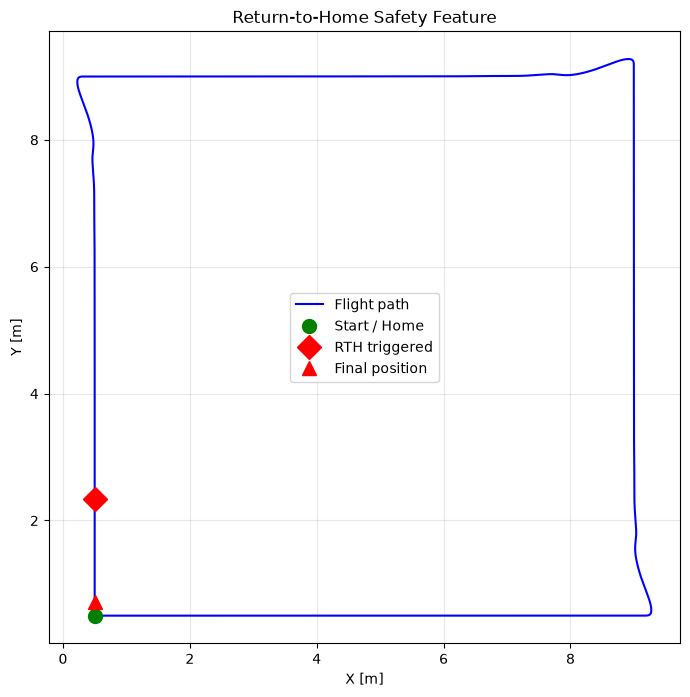

RTH triggered: True
Energy used: 168.9 / 200.0 N·s
Final distance from home: 0.247 m


In [15]:
# Exercise 1 scaffold — Return-to-Home safety feature

def run_mission_with_rth(waypoints, speed, dt, energy_budget, home_position):
    """Run a mission with return-to-home triggered when energy is low.

    Parameters
    ----------
    waypoints : (M, 3) mission waypoints
    speed : cruise speed [m/s]
    dt : simulation timestep [s]
    energy_budget : total available energy (thrust*time) [N·s]
    home_position : (3,) return-to-home position

    Returns
    -------
    dict with positions, energy_used, rth_triggered, etc.
    """
    traj = generate_waypoint_trajectory(waypoints, speed=speed, dt=dt)
    ctrl = SE3Controller(kx=6.0, kv=4.0, kR=0.6, kw=0.08)
    p = QuadrotorParams()
    state = QuadrotorState()
    state.position = waypoints[0].copy()

    positions = []
    energy_used = 0.0
    rth_triggered = False
    rth_index = -1

    N = len(traj['t'])
    for i in range(N):
        positions.append(state.position.copy())

        remaining_fraction = 1.0 - energy_used / energy_budget
        dist_home = np.linalg.norm(state.position - home_position)
        energy_to_home = dist_home / speed * p.mass * GRAVITY * 1.2

        if not rth_triggered and remaining_fraction < 0.20:
            rth_triggered = True
            rth_index = i
            rth_wps = np.array([state.position.copy(), home_position.copy()])
            traj = generate_waypoint_trajectory(rth_wps, speed=speed, dt=dt)
            N = min(N - i, len(traj['t']))
            state_copy = state.copy()
            for j in range(N):
                positions.append(state_copy.position.copy())
                th = ctrl.compute(state_copy, traj['pos'][j], traj['vel'][j],
                                  traj['acc'][j], traj['yaw'][j], p)
                energy_used += np.sum(th) * dt
                state_copy = simulate_step(state_copy, th, p, dt)
            break

        th = ctrl.compute(state, traj['pos'][i], traj['vel'][i],
                          traj['acc'][i], traj['yaw'][i], p)
        energy_used += np.sum(th) * dt
        state = simulate_step(state, th, p, dt)

    positions = np.array(positions)
    return {
        'positions': positions,
        'energy_used': energy_used,
        'rth_triggered': rth_triggered,
        'rth_index': rth_index,
    }

# Demo
home = np.array([0.5, 0.5, 1.0])
long_mission_wp = np.array([
    [0.5, 0.5, 2.0], [9.0, 0.5, 2.0], [9.0, 9.0, 2.0],
    [0.5, 9.0, 2.0], [0.5, 0.5, 2.0],
])

result = run_mission_with_rth(long_mission_wp, speed=1.0, dt=0.02,
                               energy_budget=200.0, home_position=home)

fig, ax = plt.subplots(figsize=(7, 7))
pos = result['positions']
ax.plot(pos[:, 0], pos[:, 1], 'b-', linewidth=1.5, label='Flight path')
ax.plot(pos[0, 0], pos[0, 1], 'go', markersize=10, label='Start / Home')
if result['rth_triggered'] and result['rth_index'] >= 0:
    ax.plot(pos[result['rth_index'], 0], pos[result['rth_index'], 1],
            'rD', markersize=12, label='RTH triggered')
ax.plot(pos[-1, 0], pos[-1, 1], 'r^', markersize=10, label='Final position')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
ax.set_title('Return-to-Home Safety Feature'); ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"RTH triggered: {result['rth_triggered']}")
print(f"Energy used: {result['energy_used']:.1f} / 200.0 N·s")
print(f"Final distance from home: {np.linalg.norm(pos[-1] - home):.3f} m")

## Autonomous System Architecture: The 2026 Landscape

The modular Perceive → Map → Plan → Act pipeline we built in this notebook is not a
textbook simplification — it reflects the dominant architecture in deployed autonomous
systems as of 2025–2026.  Below we survey key developments that validate and extend
this design.

### Unified Autonomy Stack (NTNU, 2025)

Researchers at the Norwegian University of Science and Technology (NTNU) developed a
**Unified Autonomy Stack** for autonomous robots operating in subterranean environments
(mines, tunnels, caves) where GPS is denied and visibility is limited.  Their architecture
follows the same layered decomposition we implement here:

| Layer | NTNU implementation | Our notebook equivalent |
|-------|--------------------|-----------------------|
| **Perception** | Multi-modal SLAM fusing LiDAR + visual–inertial odometry + thermal | EKF fusing IMU + GPS + depth (NB 20) |
| **Mapping** | Voxblox TSDF + topological graph | Log-odds occupancy grid (NB 12) |
| **Planning** | OmniPlanner — a unified planner supporting ground, aerial, and amphibious robots | A\* / RRT\* / APF (NB 21) |
| **Navigation** | Hybrid RL policy + Control Barrier Functions (CBFs) for hard safety constraints | SE(3) geometric controller (NB 19) |

The critical design choice is the **Control Barrier Function** layer between the learned
RL local planner and the physical actuators.  A CBF enforces a safety constraint
$h(x) \geq 0$ (e.g., minimum distance to walls) by modifying the RL action *only when
necessary* to keep the system inside the safe set:

$$
u_{\text{safe}} = \arg\min_{u} \|u - u_{\text{RL}}\|^2
\quad \text{s.t.} \quad \dot{h}(x, u) + \alpha(h(x)) \geq 0
$$

This gives the RL policy full freedom in the interior of the safe set, while providing a
formal guarantee that the constraint is never violated — the best of both worlds.

### Agentic UAVs (2025 Survey)

A comprehensive 2025 survey on agentic unmanned aerial vehicles proposes a **four-layer
architecture** that maps cleanly onto the Vision–Language–Action (VLA) paradigm emerging
in robotics:

```
┌──────────────────────────────────────────────────────────┐
│  Layer 4: COMMUNICATION                                   │
│  Multi-agent coordination, task allocation, consensus      │
├──────────────────────────────────────────────────────────┤
│  Layer 3: COGNITION                                       │
│  Mission planning, decision-making, LLM/VLM reasoning      │
├──────────────────────────────────────────────────────────┤
│  Layer 2: CONTROL                                         │
│  Trajectory tracking, motor allocation, safety filters      │
├──────────────────────────────────────────────────────────┤
│  Layer 1: PERCEPTION                                      │
│  Sensor fusion, state estimation, semantic understanding    │
└──────────────────────────────────────────────────────────┘
```

The survey identifies that **agentic** UAVs differ from traditional autonomous UAVs in
their ability to reason about goals, adapt mission plans in real time, and communicate
intent to human operators or other agents.  The cognition layer — increasingly powered by
vision–language models — sits between perception and control, making high-level decisions
that the lower layers execute.

This is a strict superset of our four-stage pipeline: Perceive ≈ Layer 1,
Map + Plan ≈ Layer 3, Act ≈ Layer 2, with Layer 4 adding multi-agent capabilities
explored in Exercise 3.

### The Key Insight: Layered Safety

The recurring theme across all production systems is **layered safety with explicit
guarantees at each level**:

1. **Controller level** — Lyapunov stability guarantees tracking error is bounded
   (our SE(3) controller, Theorem 2 of Lee *et al.*, 2010).
2. **Planner level** — Completeness guarantees: A\* finds a path if one exists;
   RRT\* converges to the optimal path asymptotically.
3. **Perception level** — EKF consistency: the covariance $P_k$ is a valid bound on
   estimation error under the assumed noise model.
4. **System level** — Geofencing, watchdog timers, and emergency landing (Section 11)
   provide a safety net when assumptions are violated.

Research pushes end-to-end learning for reactive performance (sub-10 ms latency from
sensor to motor), but production systems wrap learned components inside modular
architectures with formal safety contracts at each interface.  The NTNU stack
exemplifies this: RL provides agility, CBFs provide safety.

### Foundation-3D VIO: The 2026 Paradigm Shift

The most significant development in 2025-2026 is the integration of **geometric
foundation models** into the VIO pipeline:

**MASt3R-Fusion** (Sep 2025, arXiv:2509.18613): The first system to tightly couple
a feed-forward 3D foundation model (MASt3R) with IMU preintegration and GNSS in a
hierarchical factor graph.  Key innovation: converting Sim(3) visual alignment
constraints into *Hessian form* for direct integration with inertial factors.

**VIDAR** (2026): Couples SVO+IMU odometry with Depth Anything 3 for metric dense
reconstruction.  Scale error drops from 45.8% (monocular foundation model alone) to
~1% with VIO scale injection.  The "decoupled hybrid" strategy — preserve DA3 local
geometry + VIO metric scale — achieves **0.676 F@0.10** on EuRoC, surpassing
direct pose injection (0.463).

**VGGT-SLAM 2.0** (2026): Real-time dense feed-forward scene reconstruction running
on a Jetson Thor.  Uses SL(4) manifold optimisation (instead of Sim(3)) to handle
projective ambiguity in challenging scenes.

**The production layer** (egordmitriev.dev, May 2026): NVIDIA's **cuVSLAM** has
consolidated as the production standard for Jetson platforms, closing the
"I need VIO on embedded hardware" question for most teams.

### Zero-Shot Metric Depth for Navigation (2025)

A particularly impactful 2025 result enables **collision avoidance on compute-constrained
quadrotors** using only a monocular camera — no LiDAR, no stereo, no depth sensor:

**Pipeline:**
1. Run a zero-shot monocular depth network (e.g., Depth Anything V2) to get
   relative depth $\hat{d}_{\text{rel}}$ at up to 30 Hz on a mobile GPU.
2. Fuse with visual–inertial odometry (VIO) to recover metric scale via
   **monotonic spline fitting**: fit a monotonic spline $s(\cdot)$ such that
   $s(\hat{d}_{\text{rel}}) \approx d_{\text{metric}}$ using sparse VIO depth
   samples as supervision.
3. Use the metric depth map for reactive obstacle avoidance at **15 Hz** on
   platforms with $< 10\,\text{W}$ compute budget.

### Vision-Based Learning for Drones (Zhang et al., IEEE TNNLS 2025)

A comprehensive survey categorises vision-based drone control into three paradigms:

| Paradigm | Architecture | Latency | Robustness |
|----------|-------------|---------|------------|
| **Indirect** | VO/SLAM → planner → classical controller | Low | High (modular) |
| **Semidirect** | RL generates *reference signals* for geometric controller | Medium | Good |
| **End-to-end** | Pixels → motor commands (single neural network) | Very low | Fragile |

**The consensus for 2026**: Indirect and semidirect architectures dominate deployment.
End-to-end learning is advancing rapidly but requires orders of magnitude more training
data and robust sim-to-real transfer.  The hybrid approach — RL for high-level decisions,
classical control for low-level — appears to be the sweet spot.

The monotonic spline rescaling is key: monocular depth networks predict depth up to an
unknown affine transformation.  Traditional rescaling uses a single scale + shift, which
fails when the depth distortion is nonlinear.  A monotonic spline preserves ordering
while correcting nonlinear distortions, enabling metric-accurate depth from a single
camera.

$$
d_{\text{metric}}(p) = s\!\left(\hat{d}_{\text{rel}}(p)\right),
\qquad s \text{ is monotonically increasing},
\qquad \min_s \sum_{i \in \mathcal{S}} \|s(\hat{d}_{\text{rel}}(p_i)) - d_{\text{VIO}}(p_i)\|^2
$$

This result matters because it **lowers the sensor cost floor** for autonomous navigation:
a \$5 camera module + a pre-trained network replaces a \$200+ depth sensor, enabling
autonomous navigation on sub-\$100 platforms.

### Summary

The architecture we implemented in this notebook — Perceive → Map → Plan → Act with
explicit interfaces and safety layers — is not merely pedagogical.  It is the backbone
of deployed autonomous systems from research labs to commercial products, validated in
environments ranging from subterranean caves to urban airspace.